# DBTS Train-Only Diagnostic — Full Architecture (In-Sample Sanity Check)

**Goal:** Can the system learn *anything* on data it has already seen?

**Pipeline (train set only):**
1. `build_panel` — regressors (shadow + return) for ALL candidates, walk-forward OOS features
2. `GlobalSignalClassifier.fit` — trained on 100% of train, no validation split, balanced class weights
3. DBTS daily scoring — Thompson Sampling + |residual_z| + |predicted_return| + ADF
4. `PositionManager` — rules-based ENTER / HOLD / EXIT / FLIP per sector
5. Metrics + plots — Sharpe, Win Rate, Drawdown, Equity Curve

**No OOS. No tuning. No validation. Pure memorization check.**


In [13]:
# Cell 1 — TRAIN-ONLY safety switch
TRAIN_ONLY_MODE = True
ALLOW_ANY_NON_TRAIN_DATA = False

assert TRAIN_ONLY_MODE is True
assert ALLOW_ANY_NON_TRAIN_DATA is False

print("TRAIN-ONLY MODE ACTIVE")
print("TRAIN used for fitting: YES")
print("TRAIN used for DBTS diagnostics/evaluation: YES")
print("Any non-train data used: NO")


TRAIN-ONLY MODE ACTIVE
TRAIN used for fitting: YES
TRAIN used for DBTS diagnostics/evaluation: YES
Any non-train data used: NO


In [14]:
# Cell 2 — imports and project path setup
import os
import sys
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
%matplotlib inline

# Adjust this if your project lives elsewhere.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strategy").exists():
    candidate = Path(r"C:\algo-trading-project")
    if candidate.exists():
        PROJECT_ROOT = candidate

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")


Project root: c:\algo-trading-project


In [15]:
# Cell 3 — project imports
from config import SECTORS
from strategy.strategy_config import StrategyConfig
from strategy.pipeline import StrategyPipeline
from strategy.splits import chrono_split, walk_forward_folds
from strategy.predictor_selector import PredictorSelector
from strategy.regressors import DynamicShadowPriceModel, DynamicReturnModel
from strategy.residual_features import ResidualFeatureBuilder
from strategy.technical_features import TechnicalRuleFeatureBuilder
from strategy.bandit_target_selector import BanditTargetSelector
from strategy.classifier import GlobalSignalClassifier, make_labels

print("Project imports loaded.")


Project imports loaded.


In [16]:
# Cell 4 — helpers

def safe_price(prices, ticker, date):
    try:
        v = float(prices.at[date, ticker])
        return v if math.isfinite(v) and v > 0 else float("nan")
    except Exception:
        return float("nan")


def make_actual_label(price_series, cfg):
    return make_labels(price_series, cfg)


def signal_name(x):
    return {-1: "short", 0: "flat", 1: "long"}.get(int(x), str(x)) if pd.notna(x) else "nan"


def max_drawdown(equity):
    if equity.empty:
        return float("nan")
    peak = equity.cummax()
    return float((equity / peak - 1.0).min())


def pm_portfolio_metrics(pm_df, periods_per_year=252):
    """
    Portfolio metrics from PositionManager output.
    pm_df has one row per (date, sector/target) with columns:
      net_pnl, position, is_entry, is_exit, action, signal, date, sector, target
    Sectors trade in parallel → average net_pnl across active sectors per day,
    then compound.
    """
    if pm_df.empty:
        return pd.Series(dtype=float)

    # daily portfolio return = average net_pnl across all sectors that day
    daily_ret = pm_df.groupby("date")["net_pnl"].mean().sort_index()
    if daily_ret.empty:
        return pd.Series(dtype=float)

    equity = (1.0 + daily_ret).cumprod()
    cum = float(equity.iloc[-1] - 1.0)
    n = len(daily_ret)
    ann_ret = float((1.0 + cum) ** (periods_per_year / max(n, 1)) - 1.0)
    ann_vol = float(daily_ret.std(ddof=1) * np.sqrt(periods_per_year)) if n > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol != 0 else np.nan
    dn = daily_ret[daily_ret < 0]
    dn_vol = float(dn.std(ddof=1) * np.sqrt(periods_per_year)) if len(dn) > 1 else np.nan
    sortino = ann_ret / dn_vol if dn_vol and np.isfinite(dn_vol) and dn_vol != 0 else np.nan

    entries = pm_df[pm_df.get("is_entry", pd.Series(False, index=pm_df.index)) == True]
    active = pm_df[pm_df["position"] != 0]

    return pd.Series({
        "trading_days":          n,
        "total_entries":         int(len(entries)),
        "long_entries":          int((entries["position"] == 1).sum()) if not entries.empty else 0,
        "short_entries":         int((entries["position"] == -1).sum()) if not entries.empty else 0,
        "active_days":           int((active["position"] != 0).sum()),
        "cumulative_return":     round(cum, 4),
        "annualized_return":     round(ann_ret, 4),
        "annualized_volatility": round(ann_vol, 4) if np.isfinite(ann_vol) else np.nan,
        "sharpe":                round(sharpe, 4) if np.isfinite(sharpe) else np.nan,
        "sortino":               round(sortino, 4) if np.isfinite(sortino) else np.nan,
        "max_drawdown":          round(max_drawdown(equity), 4),
        "win_rate_days":         round(float((daily_ret > 0).mean()), 4),
        "avg_daily_pnl":         round(float(daily_ret.mean()), 6),
    })


In [17]:
# Cell 5 — load data and define TRAIN ONLY index
# This cell creates exactly one active date index: train_idx.
# No validation/test index is created, counted, printed, or used.

cfg = StrategyConfig(force_recompute=True, make_plots=False)
pipeline = StrategyPipeline(cfg)

print("Loading market data...")
md = pipeline.load_data()
split = chrono_split(md.prices.index, cfg)

train_idx = pd.DatetimeIndex(split.train_idx).sort_values()
horizon_buffer = int(max(getattr(cfg, "label_horizon", 1), getattr(cfg, "return_horizon", 1)))

# Dates that can safely have forward labels/exits without looking outside train.
train_fit_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]
train_run_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]

print("ACTIVE EXPERIMENT SPLIT USAGE:")
print(f"TRAIN used for fitting: YES | {train_idx[0].date()} -> {train_idx[-1].date()} | n={len(train_idx)}")
print(f"TRAIN safe fit/eval dates: {train_fit_idx[0].date()} -> {train_fit_idx[-1].date()} | n={len(train_fit_idx)}")
print("Any non-train dates used: NO")
print(f"Forward horizon buffer removed from train tail: {horizon_buffer} trading days")

assert len(train_idx) > 0
assert len(train_fit_idx) > 0
assert train_fit_idx.max() <= train_idx.max()
assert train_run_idx.max() <= train_idx.max()


Loading market data...
[cache] FORCE market_data__4adce62649ea.pkl -> computing
[fetch] 120 tickers | 2021-01-01 -> today | 1d


KeyboardInterrupt: 

In [ ]:
# Cell 6 — build TRAIN-only panel and fit classifier on 100% of TRAIN
# NO internal 80/20 split. NO validation. NO test.
# Balanced class weights are applied in the single fit call so SHORT is not suppressed.
#
# DIAGNOSTIC OVERRIDE: Production cfg uses min_train_days=756 which with 816
# train days produces only 2 walk-forward folds (~59 predict dates: Jan-Apr 2024).
# For a full-period diagnostic we override to min_train_days=120 (6 months),
# giving ~14 folds that cover the ENTIRE train period from mid-2021 onward.
# This does NOT change the production pipeline or strategy_config.py.
import dataclasses
_diag_cfg = dataclasses.replace(cfg, min_train_days=120)
train_folds = walk_forward_folds(train_fit_idx, _diag_cfg)
print(f"TRAIN-only folds (diagnostic, min_train_days=120): {len(train_folds)}")
for i, f in enumerate(train_folds, 1):
    print(f"  fold {i:02d}: train={len(f.train_idx):4d} | predict={len(f.predict_idx):3d} | retrain={f.retrain_date.date()}")

# ── Bug 1 fix: guarantee a fresh feature panel regardless of force_recompute ──
_panel_cache_path = pipeline.cache._path("feature_panel", "pkl", "panel")
if _panel_cache_path.exists():
    _panel_cache_path.unlink()
    print(f"Deleted stale feature_panel cache: {_panel_cache_path.name}")
else:
    print("No stale feature_panel cache found — building fresh.")

print("Building TRAIN-only feature panel...")
panel = pipeline.build_panel(md, train_folds, split)
panel["date"] = pd.to_datetime(panel["date"])
panel = panel[panel["date"].isin(train_fit_idx)].copy()
print(f"Panel rows after strict TRAIN-only filter: {len(panel):,}")
print(f"Panel dates covered: {panel['date'].nunique()} | {panel['date'].min().date()} → {panel['date'].max().date()}")

excluded = (
    "date", "etf", "sector", "target", "predictors", "target_price",
    "shadow_price", "next_ret", "label", "spread_signal",
    "ann_vol", "residual_z", "price_residual", "residual_ewm_mean",
    "residual_ewm_std", "residual_roll_mean", "residual_roll_std",
    # predicted_return is the raw walk-forward OOS regressor output.
    # It is kept in the panel for DBTS scoring (Cell 8) but must NOT be a
    # classifier feature — it would be a direct proxy for the label.
    "predicted_return",
    # --- Suspect leaks removed (per user request, 2026-06-03) ---
    # candidate_price : raw $-level price → non-stationary + ticker identity proxy
    # dbts_score      : aggregate of residual_z + bandit posterior + predicted_return
    #                   (residual_z & predicted_return are explicitly excluded above —
    #                    do not let them back in via this aggregate).
    # was_selected_by_dbts : 0/1 "did DBTS pick me today". At inference time it is
    #                   always 1 (we only classify the selected candidate), so it
    #                   is a soft proxy for the DBTS score itself.
    "candidate_price", "dbts_score", "was_selected_by_dbts",
)
feature_cols = [c for c in panel.columns if c not in excluded]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(panel[c])]

if not feature_cols:
    raise ValueError("No numeric feature columns found in TRAIN-only panel.")

data = panel.dropna(subset=["label"]).copy()
X = data[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.groupby(data["target"]).ffill().fillna(0.0)
for c in feature_cols:
    data[c] = X[c]
data = data.sort_values("date")

print(f"Classifier training rows — 100% TRAIN, no split: {len(data):,}")
print("Label distribution:")
display(data["label"].value_counts().sort_index().rename(index={-1: "short", 0: "flat", 1: "long"}).to_frame("count"))

# Visibility on what dropped vs. what stayed
_all_panel_cols = list(panel.columns)
_dropped_excluded = [c for c in _all_panel_cols if c in excluded]
_dropped_nonnumeric = [c for c in _all_panel_cols
                      if c not in excluded and not pd.api.types.is_numeric_dtype(panel[c])]
print(f"\nFeature accounting:")
print(f"  total panel cols : {len(_all_panel_cols)}")
print(f"  excluded         : {len(_dropped_excluded)}")
print(f"  non-numeric      : {len(_dropped_nonnumeric)} ({_dropped_nonnumeric})")
print(f"  classifier feats : {len(feature_cols)}")

# ── Fit on ALL TRAIN data with balanced class weights in one pass ───────────
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier as _XGBCls

_p = dict(cfg.clf_params)
_p.update({"num_class": 3, "objective": "multi:softprob", "verbosity": 0,
           "random_state": int(cfg.random_state)})

_X = data[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
_y = data["label"].map({-1: 0, 0: 1, 1: 2}).astype(int)
_sw = compute_sample_weight(class_weight="balanced", y=_y)

clf = GlobalSignalClassifier(cfg)
clf.features_ = feature_cols
clf_bal = _XGBCls(**_p)
clf_bal.fit(_X, _y, sample_weight=_sw)
clf.model_ = clf_bal

_wmap = {nm: round(float(_sw[(_y == i).values].mean()), 3)
         for i, nm in enumerate(["short", "flat", "long"])}
print(f"\nClassifier fit complete.")
print(f"  Samples: {len(_y):,}  |  Balanced weights: {_wmap}")

imp = pd.Series(clf_bal.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 20 feature importances:")
display(imp.head(20).to_frame("importance"))


TRAIN-only folds (diagnostic, min_train_days=120): 14
  fold 01: train= 120 | predict= 50 | retrain=2021-06-25
  fold 02: train= 170 | predict= 50 | retrain=2021-09-07
  fold 03: train= 220 | predict= 50 | retrain=2021-11-16
  fold 04: train= 270 | predict= 50 | retrain=2022-01-28
  fold 05: train= 320 | predict= 50 | retrain=2022-04-11
  fold 06: train= 370 | predict= 50 | retrain=2022-06-23
  fold 07: train= 420 | predict= 50 | retrain=2022-09-02
  fold 08: train= 470 | predict= 50 | retrain=2022-11-14
  fold 09: train= 520 | predict= 50 | retrain=2023-01-27
  fold 10: train= 570 | predict= 50 | retrain=2023-04-11
  fold 11: train= 620 | predict= 50 | retrain=2023-06-22
  fold 12: train= 670 | predict= 50 | retrain=2023-09-01
  fold 13: train= 720 | predict= 50 | retrain=2023-11-13
  fold 14: train= 770 | predict= 46 | retrain=2024-01-26
No stale feature_panel cache found — building fresh.
Building TRAIN-only feature panel...
[cache] FORCE feature_panel__4e683b3501b5.pkl -> computing

,count
label,
short,7526
flat,60776
long,6888



Feature accounting:
  total panel cols : 87
  excluded         : 20
  non-numeric      : 0 ([])
  classifier feats : 67

Classifier fit complete.
  Samples: 75,190  |  Balanced weights: {'short': 3.33, 'flat': 0.412, 'long': 3.639}
Top 20 feature importances:


,importance
residual_ewm_z,0.278757
residual_excursion_bucket,0.276226
price_residual_z,0.250444
residual_rank,0.058475
residual_percentile,0.038688
residual_abs_z,0.023239
rule_breakout_20,0.005673
shadow_price_gap_pct,0.002779
residual_ewm_slope,0.002690
residual_half_life_proxy,0.002293


In [ ]:
# Cell 6b — panel shape diagnostic
print(f"panel total rows:         {len(panel):,}")
print(f"panel dates (unique):     {panel['date'].nunique()}")
print(f"panel date range:         {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"panel targets (unique):   {panel['target'].nunique() if 'target' in panel.columns else panel.get('candidate', panel).nunique()}")
print(f"panel label non-NaN rows: {panel['label'].notna().sum():,}")
print(f"panel predicted_return:   {'YES' in str('YES' if 'predicted_return' in panel.columns else 'NO')}")
print(f"\ntrain_fit_idx range: {train_fit_idx[0].date()} → {train_fit_idx[-1].date()} | n={len(train_fit_idx)}")
print(f"train_folds: {len(train_folds)} folds")
if train_folds:
    print(f"  first fold predict_idx: {train_folds[0].predict_idx[0].date()} → {train_folds[0].predict_idx[-1].date()}")
    print(f"  last  fold predict_idx: {train_folds[-1].predict_idx[0].date()} → {train_folds[-1].predict_idx[-1].date()}")


panel total rows:         76,560
panel dates (unique):     696
panel date range:         2021-06-25 → 2024-04-02
panel targets (unique):   110
panel label non-NaN rows: 75,190
panel predicted_return:   True

train_fit_idx range: 2021-01-04 → 2024-04-02 | n=816
train_folds: 14 folds
  first fold predict_idx: 2021-06-25 → 2021-09-03
  last  fold predict_idx: 2024-01-26 → 2024-04-02


---

## SECTION B — Label Diagnostics (Cells 6c → 6i)

These cells were the investigative chain that led to the **production switch to reversion labels** now active in `strategy/pipeline.py` (`cfg.use_reversion_labels=True`).

### Run order (top-to-bottom)
| # | Cell | Produces (used by later cells) |
|---|---|---|
| 6c | OPTION C diagnostic A/B | `clf_old`, `clf_new`, `panel_rev`, `feature_cols` |
| 6d | Horizon sweep (Check 3) | `res_df` |
| 6e | Bucketed horizon sweep | `res_b` |
| 6f | Upstream residual_z audit | `audit` |
| 6g | PM sweep on prod labels (zero trades) | `res_df` (sweep) |
| 6h | Entry-gate funnel | reveals classifier saturation |
| 6i | A/B PM with reversion classifier | `clf_h12`, `sp_h12`, `sweep_df` — the validating run |

### Re-running for fresh comparison
Production now uses reversion labels, so `panel["label"]` IS the reversion label. To reproduce the OLD vs NEW A/B in 6c, temporarily set `cfg.use_reversion_labels = False` before Cell 5 and re-run Cells 5 → 6.

### Production change applied
- `strategy/strategy_config.py`: added `use_reversion_labels` (=True), `reversion_label_horizon` (=5), `reversion_entry_band` (=1.0), `reversion_close_band` (=0.5), `use_class_balanced_weights` (=True).
- `strategy/pipeline.py`: `build_panel` emits reversion labels from `residual_ewm_z` when the flag is on.
- `strategy/classifier.py`: `fit` applies `class_weight='balanced'` sample weights when the flag is on.

---

OPTION C DIAGNOSTIC — reversion-based labels (no production changes)
Parameters: h=5 days | entry_band=1.0 | close_band=0.5

── CHECK 1: Reversion label distribution ──
  Valid rows: 75,190 / 76,560 (98.2%)


,share
label_reversion,
short,0.1001
flat,0.8083
long,0.0916


  ✓ flat share 80.8% — within healthy range.

── CHECK 2: Economic validity (label vs realized residual_z change) ──


,count,mean,median,std
label_reversion,,,,
short(-1),7526,-1.3591,-1.0645,0.9835
flat(0),60776,0.0196,0.0184,0.8548
long(+1),6888,1.3240,1.0497,1.1910


  Expected:  long(+1) mean delta_rz > 0  (got 1.324)
             short(-1) mean delta_rz < 0 (got -1.359)
  Tautology note: labels are derived from delta_rz, so signs MUST match by construction.
  Real check: |mean delta| should be substantially > close_band=0.5.

── CHECK 3: Base rate of reversion ──
  Of all panel rows with |residual_z| > 1.0,
  what % have |residual_z(t+5)| < 0.5?
  n extreme rows: 28,070
  base rate of reversion: 17.8%
  starts expensive (rz>+1.0): reversion rate = 16.1% (n=15,114)
  starts cheap     (rz<-1.0): reversion rate = 19.7% (n=12,956)

  ⚠ Base rate < 25% — reversion is weak in this data. 
     Switching label scheme alone is unlikely to fix the engine.

── CHECK 4: A/B classifier max-prob comparison (same X, two labels) ──
  Aligned rows for A/B: 75,190
  y_old (fwd_return ±1%) distribution: {'flat': 60776, 'short': 7526, 'long': 6888}
  y_new (reversion)     distribution: {'flat': 60776, 'short': 7526, 'long': 6888}



,max_prob_threshold,OLD pass_n,OLD pass_%,NEW pass_n,NEW pass_%
0,0.40,75190,100.00,75190,100.00
1,0.45,75190,100.00,75190,100.00
2,0.50,75190,100.00,75190,100.00
3,0.55,75181,99.99,75181,99.99
4,0.60,75165,99.97,75165,99.97
5,0.65,75141,99.93,75141,99.93
6,0.70,75060,99.83,75060,99.83


  OLD max-prob: mean=0.955 | median=1.000 | max=1.000
  NEW max-prob: mean=0.955 | median=1.000 | max=1.000

  Δ pass-rate at 0.60 gate: +0.00 percentage points
  ✗ No improvement — softmax flatness is driven by the FEATURES, not the labels.



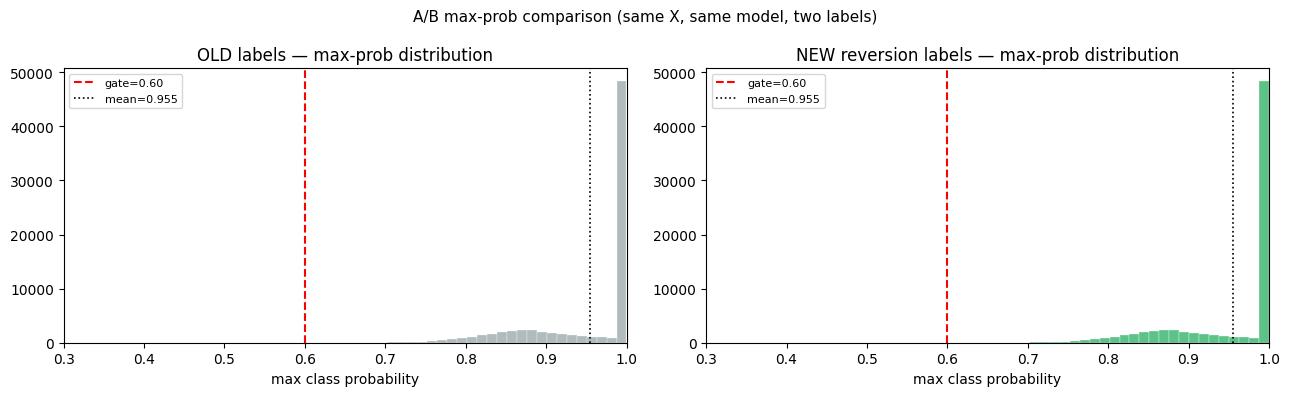

END OPTION C DIAGNOSTIC — production cfg/classifier untouched.


In [ ]:
# Cell 6c — OPTION C diagnostic: reversion-based labels (A/B vs current)
# READ-ONLY w.r.t. production:
#   - does NOT modify build_panel, strategy_config, or make_labels.
#   - re-uses the already-built `panel`, `feature_cols`, and `data` from Cell 6.
#   - trains a second XGBClassifier on the same X with reversion labels, then
#     compares the max-prob distribution on the same rows.
#
# Four checks per the analysis:
#   1. Label distribution under option C (target: ~70-80% flat, ~10-15% each side)
#   2. Economic validity: do +1 labels actually correspond to rz reverting up?
#   3. Base rate of reversion: of all |rz|>1 events, what % revert within h days?
#   4. A/B: max-prob distribution of NEW classifier vs CURRENT classifier on same rows.
#
# DOES NOT change cfg, classifier, build_panel, or PositionManager.

from strategy.reversion_labels import make_reversion_labels_on_panel
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier as _XGBCls_rev

# Tunable diagnostic parameters (NOT written back to cfg)
REV_H          = 5     # reversion horizon (days)
REV_ENTRY_BAND = 1.0   # |rz| must exceed this to be a candidate for non-flat label
REV_CLOSE_BAND = 0.5   # rz must move at least this much in the closing direction

print("=" * 70)
print("OPTION C DIAGNOSTIC — reversion-based labels (no production changes)")
print("=" * 70)
print(f"Parameters: h={REV_H} days | entry_band={REV_ENTRY_BAND} | close_band={REV_CLOSE_BAND}")
print()

# ── Build reversion labels on the existing panel ───────────────────────────
rev_labels = make_reversion_labels_on_panel(
    panel, h=REV_H, entry_band=REV_ENTRY_BAND, close_band=REV_CLOSE_BAND,
    date_col="date", cand_col="target", rz_col="residual_z",
)
panel_rev = panel.copy()
panel_rev["label_reversion"] = rev_labels.values

# ──────────────────────────────────────────────────────────────────────────
# CHECK 1 — Label distribution
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 1: Reversion label distribution ──")
valid_rev = panel_rev.dropna(subset=["label_reversion"])
dist = (valid_rev["label_reversion"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index={-1.0: "short", 0.0: "flat", 1.0: "long"}))
print(f"  Valid rows: {len(valid_rev):,} / {len(panel_rev):,} "
      f"({len(valid_rev)/max(1,len(panel_rev))*100:.1f}%)")
display(dist.to_frame("share").round(4))
flat_pct = float(dist.get("flat", 0)) * 100
if flat_pct > 95:
    print(f"  ⚠ flat={flat_pct:.1f}% — entry_band={REV_ENTRY_BAND} may be too wide, "
          "or reversion is rare. Consider lowering entry_band.")
elif flat_pct < 50:
    print(f"  ⚠ flat={flat_pct:.1f}% — entry_band={REV_ENTRY_BAND} too narrow.")
else:
    print(f"  ✓ flat share {flat_pct:.1f}% — within healthy range.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 2 — Economic validity (label vs realized rz_future)
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 2: Economic validity (label vs realized residual_z change) ──")
# Build rz_future per candidate (same shift used internally) for verification.
panel_sorted = panel_rev.sort_values(["target", "date"]).copy()
panel_sorted["residual_z_future"] = panel_sorted.groupby("target")["residual_z"].shift(-REV_H)
panel_sorted["delta_rz"] = panel_sorted["residual_z_future"] - panel_sorted["residual_z"]

econ = (panel_sorted.dropna(subset=["label_reversion", "delta_rz"])
        .groupby("label_reversion")["delta_rz"]
        .agg(["count", "mean", "median", "std"])
        .round(4)
        .rename(index={-1.0: "short(-1)", 0.0: "flat(0)", 1.0: "long(+1)"}))
display(econ)
mean_long  = econ.loc["long(+1)", "mean"]  if "long(+1)"  in econ.index else float("nan")
mean_short = econ.loc["short(-1)", "mean"] if "short(-1)" in econ.index else float("nan")
print(f"  Expected:  long(+1) mean delta_rz > 0  (got {mean_long:.3f})")
print(f"             short(-1) mean delta_rz < 0 (got {mean_short:.3f})")
print(f"  Tautology note: labels are derived from delta_rz, so signs MUST match by construction.")
print(f"  Real check: |mean delta| should be substantially > close_band={REV_CLOSE_BAND}.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 3 — Base rate of reversion
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 3: Base rate of reversion ──")
print(f"  Of all panel rows with |residual_z| > {REV_ENTRY_BAND},")
print(f"  what % have |residual_z(t+{REV_H})| < {REV_CLOSE_BAND}?")
extreme = panel_sorted.dropna(subset=["residual_z", "residual_z_future"])
extreme = extreme[extreme["residual_z"].abs() > REV_ENTRY_BAND]
if len(extreme) > 0:
    reverted_mask = extreme["residual_z_future"].abs() < REV_CLOSE_BAND
    rev_rate = float(reverted_mask.mean())
    print(f"  n extreme rows: {len(extreme):,}")
    print(f"  base rate of reversion: {rev_rate*100:.1f}%")
    # Stratify by direction
    pos_ext = extreme[extreme["residual_z"] > REV_ENTRY_BAND]
    neg_ext = extreme[extreme["residual_z"] < -REV_ENTRY_BAND]
    if len(pos_ext):
        print(f"  starts expensive (rz>+{REV_ENTRY_BAND}): "
              f"reversion rate = {(pos_ext['residual_z_future'].abs() < REV_CLOSE_BAND).mean()*100:.1f}% "
              f"(n={len(pos_ext):,})")
    if len(neg_ext):
        print(f"  starts cheap     (rz<-{REV_ENTRY_BAND}): "
              f"reversion rate = {(neg_ext['residual_z_future'].abs() < REV_CLOSE_BAND).mean()*100:.1f}% "
              f"(n={len(neg_ext):,})")
    print()
    if rev_rate < 0.25:
        print(f"  ⚠ Base rate < 25% — reversion is weak in this data. ")
        print(f"     Switching label scheme alone is unlikely to fix the engine.")
    elif rev_rate > 0.40:
        print(f"  ✓ Base rate > 40% — reversion exists; classifier has signal to learn.")
    else:
        print(f"  ~ Base rate {rev_rate*100:.1f}% — borderline; option C may help marginally.")
else:
    print("  No extreme rows found — check is inconclusive.")
print()

# ──────────────────────────────────────────────────────────────────────────
# CHECK 4 — A/B classifier max-prob comparison
# ──────────────────────────────────────────────────────────────────────────
print("── CHECK 4: A/B classifier max-prob comparison (same X, two labels) ──")
# Build aligned dataset: rows where BOTH label schemes are defined.
both = panel_rev.dropna(subset=["label", "label_reversion"]).copy()
X_ab = both[feature_cols].apply(pd.to_numeric, errors="coerce")
X_ab = X_ab.groupby(both["target"]).ffill().fillna(0.0)
y_old = both["label"].map({-1: 0, 0: 1, 1: 2}).astype(int)
y_new = both["label_reversion"].map({-1.0: 0, 0.0: 1, 1.0: 2}).astype(int)

print(f"  Aligned rows for A/B: {len(both):,}")
print(f"  y_old (fwd_return ±1%) distribution: "
      f"{dict(y_old.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print(f"  y_new (reversion)     distribution: "
      f"{dict(y_new.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print()

_p_ab = dict(cfg.clf_params)
_p_ab.update({"num_class": 3, "objective": "multi:softprob",
              "verbosity": 0, "random_state": int(cfg.random_state)})

clf_old = _XGBCls_rev(**_p_ab)
sw_old = compute_sample_weight(class_weight="balanced", y=y_old)
clf_old.fit(X_ab, y_old, sample_weight=sw_old)

clf_new = _XGBCls_rev(**_p_ab)
sw_new = compute_sample_weight(class_weight="balanced", y=y_new)
clf_new.fit(X_ab, y_new, sample_weight=sw_new)

proba_old = clf_old.predict_proba(X_ab)
proba_new = clf_new.predict_proba(X_ab)
maxp_old = proba_old.max(axis=1)
maxp_new = proba_new.max(axis=1)

ab_rows = []
for thr in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    ab_rows.append({
        "max_prob_threshold": thr,
        "OLD pass_n": int((maxp_old >= thr).sum()),
        "OLD pass_%": round((maxp_old >= thr).mean() * 100, 2),
        "NEW pass_n": int((maxp_new >= thr).sum()),
        "NEW pass_%": round((maxp_new >= thr).mean() * 100, 2),
    })
ab_df = pd.DataFrame(ab_rows)
display(ab_df)

print(f"  OLD max-prob: mean={maxp_old.mean():.3f} | median={np.median(maxp_old):.3f} "
      f"| max={maxp_old.max():.3f}")
print(f"  NEW max-prob: mean={maxp_new.mean():.3f} | median={np.median(maxp_new):.3f} "
      f"| max={maxp_new.max():.3f}")

gain_at_60 = ab_df.loc[ab_df["max_prob_threshold"] == 0.60, "NEW pass_%"].values[0] - \
             ab_df.loc[ab_df["max_prob_threshold"] == 0.60, "OLD pass_%"].values[0]
print()
print(f"  Δ pass-rate at 0.60 gate: {gain_at_60:+.2f} percentage points")
if gain_at_60 > 5:
    print("  ✓ Reversion labels produce noticeably sharper softmax — option C looks promising.")
elif gain_at_60 > 1:
    print("  ~ Mild improvement — option C helps a little; main bottleneck likely elsewhere (features).")
else:
    print("  ✗ No improvement — softmax flatness is driven by the FEATURES, not the labels.")
print()

# Side-by-side histogram of max-prob distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(maxp_old, bins=40, alpha=0.75, color="#95a5a6", edgecolor="white", lw=0.3)
axes[0].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[0].axvline(maxp_old.mean(), color="black", lw=1.2, ls=":", label=f"mean={maxp_old.mean():.3f}")
axes[0].set_title("OLD labels — max-prob distribution"); axes[0].set_xlim(0.30, 1.0)
axes[0].legend(fontsize=8); axes[0].set_xlabel("max class probability")

axes[1].hist(maxp_new, bins=40, alpha=0.75, color="#27ae60", edgecolor="white", lw=0.3)
axes[1].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[1].axvline(maxp_new.mean(), color="black", lw=1.2, ls=":", label=f"mean={maxp_new.mean():.3f}")
axes[1].set_title("NEW reversion labels — max-prob distribution"); axes[1].set_xlim(0.30, 1.0)
axes[1].legend(fontsize=8); axes[1].set_xlabel("max class probability")
plt.suptitle("A/B max-prob comparison (same X, same model, two labels)", fontsize=11)
plt.tight_layout(); plt.show()

print("=" * 70)
print("END OPTION C DIAGNOSTIC — production cfg/classifier untouched.")
print("=" * 70)


CHECK 3 SWEEP — base rate of reversion across horizons
  entry_band = 1.0  (|rz_now| must exceed this)
  close_bands = [0.3, 0.5]  (|rz_future| must fall below this)
  horizons    = [1, 2, 3, 5, 8, 12, 20, 30] trading days

── Reversion rates (%) and divergence (%) by horizon ──
 h  n_extreme  n_pos  n_neg  rev_all_<0.3  rev_pos_<0.3  rev_neg_<0.3  rev_all_<0.5  rev_pos_<0.5  rev_neg_<0.5  mean_|rz_future|_extreme  frac_diverged_extreme
 1      28219  15234  12985           2.7           2.3           3.1           5.2           4.7           5.7                     1.368                   32.8
 2      28182  15203  12979           5.0           4.4           5.8           9.4           8.4          10.7                     1.262                   28.0
 3      28141  15169  12972           6.9           6.2           7.8          12.7          11.5          14.1                     1.184                   25.2
 5      28070  15114  12956          10.0           8.9          11.3       

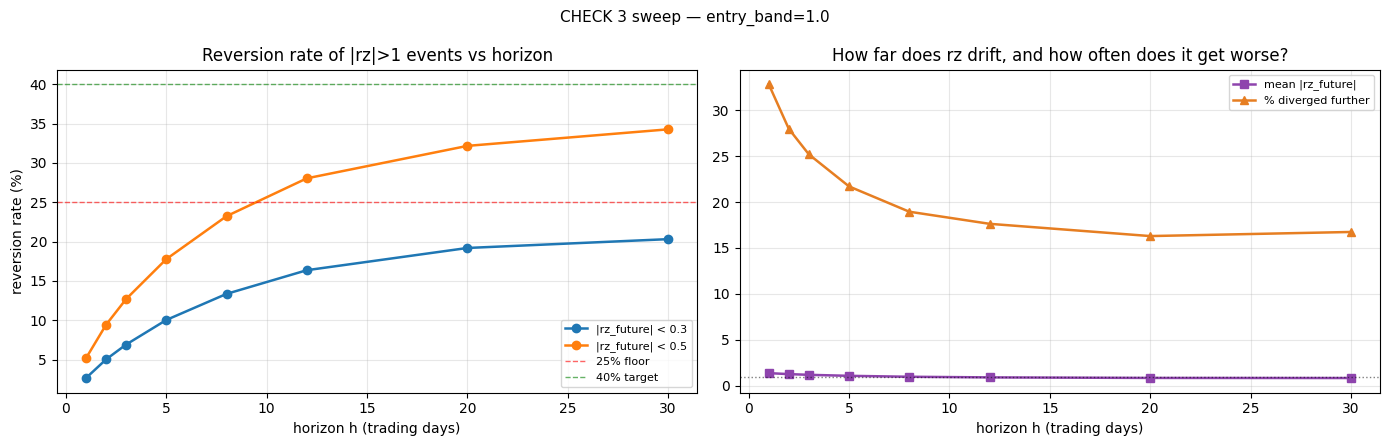

── Verdict ──
  ~ Borderline. Best loose rate = 34.3%, best tight rate = 20.3%.
    Marginal candidate; expect modest PnL even if everything else works.


In [ ]:
# Cell 6d — CHECK 3 horizon sweep: base-rate of reversion across h
# Question: at what horizon (if any) does reversion become common enough
# (>= 25-40%) to make the mean-reversion engine viable on this data?
#
# Reads `panel` from Cell 6 (must be in kernel).
# Does NOT modify cfg, classifier, build_panel, or anything in production.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTRY_BAND   = 1.0                          # entry threshold (matches PM gate)
CLOSE_BANDS  = [0.30, 0.50]                 # "reverted" = |rz_future| < this
HORIZONS     = [1, 2, 3, 5, 8, 12, 20, 30]  # trading days

print("=" * 78)
print("CHECK 3 SWEEP — base rate of reversion across horizons")
print("=" * 78)
print(f"  entry_band = {ENTRY_BAND}  (|rz_now| must exceed this)")
print(f"  close_bands = {CLOSE_BANDS}  (|rz_future| must fall below this)")
print(f"  horizons    = {HORIZONS} trading days")
print()

# Pre-sort once, compute rz_future for each h
panel_sweep = panel.sort_values(["target", "date"]).copy()
results = []

for h in HORIZONS:
    rz_future = panel_sweep.groupby("target")["residual_z"].shift(-h)
    df = pd.DataFrame({
        "rz_now":    panel_sweep["residual_z"].values,
        "rz_future": rz_future.values,
    }).dropna()

    extreme = df[df["rz_now"].abs() > ENTRY_BAND]
    pos = extreme[extreme["rz_now"] >  ENTRY_BAND]   # starts expensive
    neg = extreme[extreme["rz_now"] < -ENTRY_BAND]   # starts cheap

    row = {"h": h, "n_extreme": len(extreme),
           "n_pos": len(pos), "n_neg": len(neg)}
    for cb in CLOSE_BANDS:
        row[f"rev_all_<{cb}"]  = float((extreme["rz_future"].abs() < cb).mean()) if len(extreme) else np.nan
        row[f"rev_pos_<{cb}"]  = float((pos["rz_future"].abs() < cb).mean())     if len(pos)     else np.nan
        row[f"rev_neg_<{cb}"]  = float((neg["rz_future"].abs() < cb).mean())     if len(neg)     else np.nan
    # Also: mean |rz_future| — how much it relaxes on average
    row["mean_|rz_future|_extreme"] = float(extreme["rz_future"].abs().mean()) if len(extreme) else np.nan
    # And: fraction that DIVERGED further
    row["frac_diverged_extreme"] = float((extreme["rz_future"].abs() > extreme["rz_now"].abs()).mean()) if len(extreme) else np.nan
    results.append(row)

res_df = pd.DataFrame(results)

# Pretty-print rates as percentages
pct_cols = [c for c in res_df.columns if c.startswith(("rev_", "frac_"))]
disp = res_df.copy()
for c in pct_cols:
    disp[c] = (disp[c] * 100).round(1)
disp["mean_|rz_future|_extreme"] = disp["mean_|rz_future|_extreme"].round(3)

print("── Reversion rates (%) and divergence (%) by horizon ──")
print(disp.to_string(index=False))
print()

# ── Interpretation guides ─────────────────────────────────────────────
best_close = CLOSE_BANDS[-1]   # 0.50 — easier bar
best_row = res_df.loc[res_df[f"rev_all_<{best_close}"].idxmax()]
print(f"── Best horizon at close_band={best_close} ──")
print(f"   h={int(best_row['h'])} → reversion rate = {best_row[f'rev_all_<{best_close}']*100:.1f}%")
print(f"   n_extreme={int(best_row['n_extreme']):,}, diverged_further={best_row['frac_diverged_extreme']*100:.1f}%")
print()

tight_close = CLOSE_BANDS[0]   # 0.30 — PM's actual mean_reversion_exit
best_row_tight = res_df.loc[res_df[f"rev_all_<{tight_close}"].idxmax()]
print(f"── Best horizon at PM exit threshold close_band={tight_close} ──")
print(f"   h={int(best_row_tight['h'])} → reversion rate = {best_row_tight[f'rev_all_<{tight_close}']*100:.1f}%")
print(f"   (This is the actual PM exit gate — much stricter.)")
print()

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for cb in CLOSE_BANDS:
    ax.plot(res_df["h"], res_df[f"rev_all_<{cb}"] * 100,
            marker="o", lw=1.8, label=f"|rz_future| < {cb}")
ax.axhline(25, color="red",    ls="--", lw=1, alpha=0.6, label="25% floor")
ax.axhline(40, color="green",  ls="--", lw=1, alpha=0.6, label="40% target")
ax.set_xlabel("horizon h (trading days)")
ax.set_ylabel("reversion rate (%)")
ax.set_title("Reversion rate of |rz|>1 events vs horizon")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(res_df["h"], res_df["mean_|rz_future|_extreme"],
        marker="s", color="#8e44ad", lw=1.8, label="mean |rz_future|")
ax.plot(res_df["h"], res_df["frac_diverged_extreme"] * 100,
        marker="^", color="#e67e22", lw=1.8, label="% diverged further")
ax.axhline(ENTRY_BAND, color="black", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("horizon h (trading days)")
ax.set_title("How far does rz drift, and how often does it get worse?")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f"CHECK 3 sweep — entry_band={ENTRY_BAND}", fontsize=11)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────
print("── Verdict ──")
max_rate_loose = res_df[f"rev_all_<{best_close}"].max() * 100
max_rate_tight = res_df[f"rev_all_<{tight_close}"].max() * 100
if max_rate_tight < 15 and max_rate_loose < 25:
    print("  ✗ Reversion is rare across ALL tested horizons.")
    print("    Root cause is upstream (shadow_price model, pair selection,")
    print("    or residual_z normalization) — NOT labels or classifier.")
elif max_rate_tight >= 25 or max_rate_loose >= 40:
    print(f"  ✓ Reversion is viable at some horizon.")
    print(f"     Best h={int(best_row['h'])} (close_band={best_close}) "
          f"= {max_rate_loose:.1f}%")
    print(f"     Consider testing label_horizon = {int(best_row['h'])} in Option C labels.")
else:
    print(f"  ~ Borderline. Best loose rate = {max_rate_loose:.1f}%, "
          f"best tight rate = {max_rate_tight:.1f}%.")
    print("    Marginal candidate; expect modest PnL even if everything else works.")


CHECK 3 SWEEP BY BUCKET — reversion rate by |rz_now| and horizon
  bucket 1.0-1.5   n_total= 16,672
  bucket 1.5-2.0   n_total=  7,551
  bucket 2.0-2.5   n_total=  2,590
  bucket 2.5+      n_total=  1,444

── Reversion rate (%) with |rz_future| < 0.3 ──
h         1    2    3     5     8     12    20    30
bucket                                              
1.0-1.5  3.4  6.4  8.5  11.7  15.2  17.5  19.2  20.3
1.5-2.0  1.7  3.2  4.9   8.2  11.5  15.9  19.7  20.3
2.0-2.5  1.4  2.9  4.1   6.6   9.5  12.8  18.6  20.6
2.5+     1.7  2.8  4.2   6.6   9.0  12.0  17.9  19.4

── Reversion rate (%) with |rz_future| < 0.5 ──
h         1     2     3     5     8     12    20    30
bucket                                                
1.0-1.5  6.8  12.0  15.7  21.0  26.6  30.2  32.5  34.1
1.5-2.0  3.1   6.1   9.0  14.1  19.8  27.0  32.3  34.4
2.0-2.5  2.2   4.9   7.2  11.8  16.3  21.6  31.0  35.1
2.5+     3.4   5.1   7.3  10.3  14.7  19.6  30.0  34.5

── Sample sizes (n) per bucket × h ──
h         

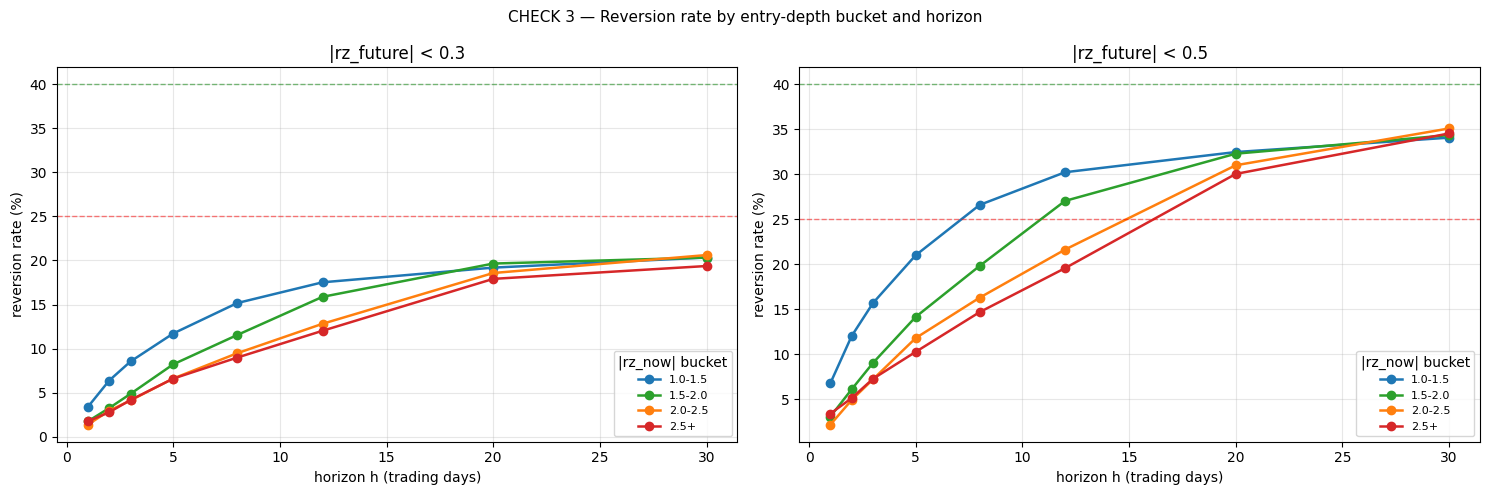

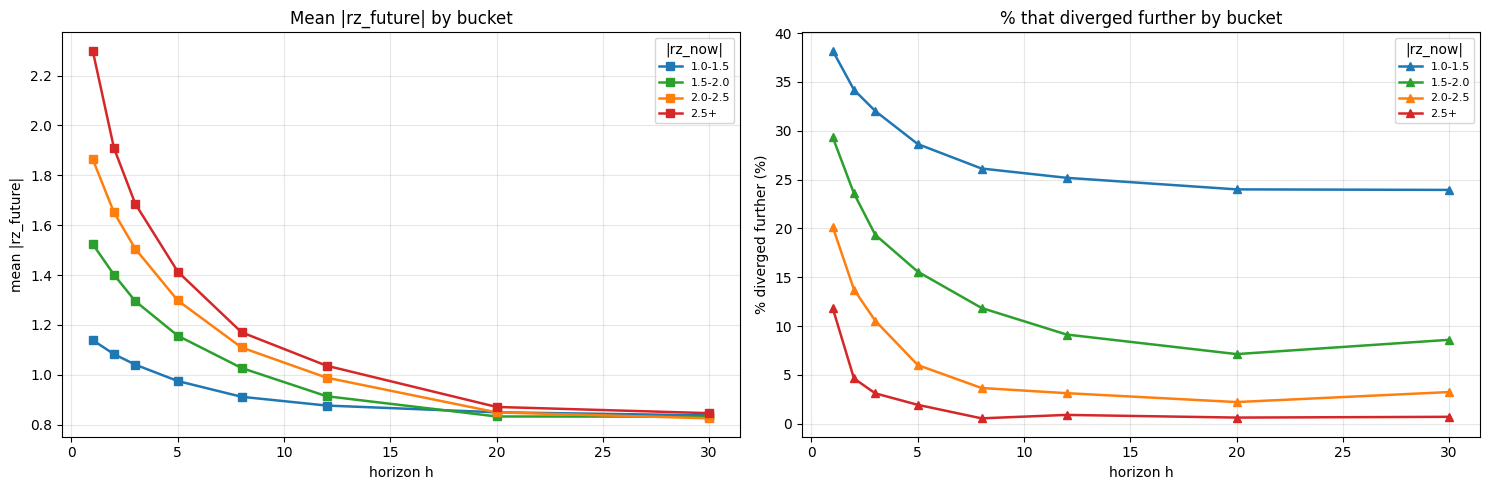

── Best (bucket, h) for PM exit threshold (close < 0.30) ──
   bucket=2.0-2.5, h=30, rev=20.6%, n=2,493

── Best (bucket, h) at loose threshold (close < 0.50) ──
   bucket=2.0-2.5, h=30, rev=35.1%, n=2,493


In [ ]:
# Cell 6e — CHECK 3 sweep, BUCKETED by |rz_now|
# Same logic as Cell 6d, but split into residual buckets:
#   [1.0, 1.5), [1.5, 2.0), [2.0, 2.5), [2.5, +inf)
# Question: do deeper extremes revert more often?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLOSE_BANDS = [0.30, 0.50]
HORIZONS    = [1, 2, 3, 5, 8, 12, 20, 30]
BUCKETS = [
    ("1.0-1.5", 1.0, 1.5),
    ("1.5-2.0", 1.5, 2.0),
    ("2.0-2.5", 2.0, 2.5),
    ("2.5+",    2.5, np.inf),
]

print("=" * 78)
print("CHECK 3 SWEEP BY BUCKET — reversion rate by |rz_now| and horizon")
print("=" * 78)

panel_sweep = panel.sort_values(["target", "date"]).copy()

# Precompute rz_future per horizon once
rz_future_by_h = {
    h: panel_sweep.groupby("target")["residual_z"].shift(-h).values
    for h in HORIZONS
}
rz_now_all = panel_sweep["residual_z"].values
abs_rz_now = np.abs(rz_now_all)

# Build long-format result table: one row per (bucket, h)
rows = []
for bname, lo, hi in BUCKETS:
    mask_bucket = (abs_rz_now >= lo) & (abs_rz_now < hi)
    n_bucket_total = int(mask_bucket.sum())
    for h in HORIZONS:
        rzf = rz_future_by_h[h]
        m = mask_bucket & ~np.isnan(rzf) & ~np.isnan(rz_now_all)
        n = int(m.sum())
        row = {"bucket": bname, "h": h, "n": n}
        if n == 0:
            for cb in CLOSE_BANDS:
                row[f"rev_<{cb}"] = np.nan
            row["mean_|rz_future|"] = np.nan
            row["frac_diverged"]    = np.nan
        else:
            rzf_m = rzf[m]
            rzn_m = rz_now_all[m]
            for cb in CLOSE_BANDS:
                row[f"rev_<{cb}"] = float((np.abs(rzf_m) < cb).mean())
            row["mean_|rz_future|"] = float(np.abs(rzf_m).mean())
            row["frac_diverged"]    = float((np.abs(rzf_m) > np.abs(rzn_m)).mean())
        rows.append(row)
    print(f"  bucket {bname:<8}  n_total={n_bucket_total:>7,}")

res_b = pd.DataFrame(rows)

# Pretty print — pivot per close_band
print()
for cb in CLOSE_BANDS:
    pv = res_b.pivot(index="bucket", columns="h", values=f"rev_<{cb}") * 100
    pv = pv.reindex([b[0] for b in BUCKETS])
    pv = pv.round(1)
    print(f"── Reversion rate (%) with |rz_future| < {cb} ──")
    print(pv.to_string())
    print()

# n per bucket × h
pv_n = res_b.pivot(index="bucket", columns="h", values="n").reindex([b[0] for b in BUCKETS])
print("── Sample sizes (n) per bucket × h ──")
print(pv_n.to_string())
print()

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"1.0-1.5": "#1f77b4", "1.5-2.0": "#2ca02c",
          "2.0-2.5": "#ff7f0e", "2.5+":    "#d62728"}

for ax, cb in zip(axes, CLOSE_BANDS):
    for bname, _, _ in BUCKETS:
        sub = res_b[res_b["bucket"] == bname].sort_values("h")
        ax.plot(sub["h"], sub[f"rev_<{cb}"] * 100,
                marker="o", lw=1.8, color=colors[bname], label=bname)
    ax.axhline(25, color="red",   ls="--", lw=1, alpha=0.5)
    ax.axhline(40, color="green", ls="--", lw=1, alpha=0.5)
    ax.set_xlabel("horizon h (trading days)")
    ax.set_ylabel("reversion rate (%)")
    ax.set_title(f"|rz_future| < {cb}")
    ax.legend(title="|rz_now| bucket", fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("CHECK 3 — Reversion rate by entry-depth bucket and horizon",
             fontsize=11)
plt.tight_layout()
plt.show()

# Second figure: mean |rz_future| and diverged fraction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for bname, _, _ in BUCKETS:
    sub = res_b[res_b["bucket"] == bname].sort_values("h")
    axes[0].plot(sub["h"], sub["mean_|rz_future|"],
                 marker="s", lw=1.8, color=colors[bname], label=bname)
    axes[1].plot(sub["h"], sub["frac_diverged"] * 100,
                 marker="^", lw=1.8, color=colors[bname], label=bname)
axes[0].set_xlabel("horizon h"); axes[0].set_ylabel("mean |rz_future|")
axes[0].set_title("Mean |rz_future| by bucket")
axes[0].legend(title="|rz_now|", fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("horizon h"); axes[1].set_ylabel("% diverged further (%)")
axes[1].set_title("% that diverged further by bucket")
axes[1].legend(title="|rz_now|", fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Best (bucket, h) at PM exit threshold 0.30 ──
print("── Best (bucket, h) for PM exit threshold (close < 0.30) ──")
best = res_b.loc[res_b["rev_<0.3"].idxmax()]
print(f"   bucket={best['bucket']}, h={int(best['h'])}, "
      f"rev={best['rev_<0.3']*100:.1f}%, n={int(best['n']):,}")
print()
print("── Best (bucket, h) at loose threshold (close < 0.50) ──")
best = res_b.loc[res_b["rev_<0.5"].idxmax()]
print(f"   bucket={best['bucket']}, h={int(best['h'])}, "
      f"rev={best['rev_<0.5']*100:.1f}%, n={int(best['n']):,}")


UPSTREAM AUDIT — residual_z stationarity & mean-reversion strength

── Per-target audit (sorted by ADF p-value, lowest = most stationary) ──
target  n_obs  mean_rz  std_rz  frac_|rz|>1  AR1_rho  half_life_d  ADF_p stationary  drift_pos@h=12  drift_neg@h=12  n_pos  n_neg
    AA    694    0.029   1.160         35.2    0.794          3.0 0.0000        yes          -1.345           1.317    120    122
  ABBV    694    0.166   1.830         42.2    0.532          1.1 0.0000        yes          -1.071           1.305    190    101
   ALB    694    0.002   1.080         40.6    0.866          4.8 0.0000        yes          -0.950           0.789    133    149
   AMD    694    0.121   1.074         34.1    0.877          5.3 0.0000        yes          -1.314           1.200    136    101
  AMZN    694    0.064   1.105         38.0    0.859          4.6 0.0000        yes          -1.028           1.061    141    116
   AMT    694    0.017   1.076         36.6    0.875          5.2 0.0000       

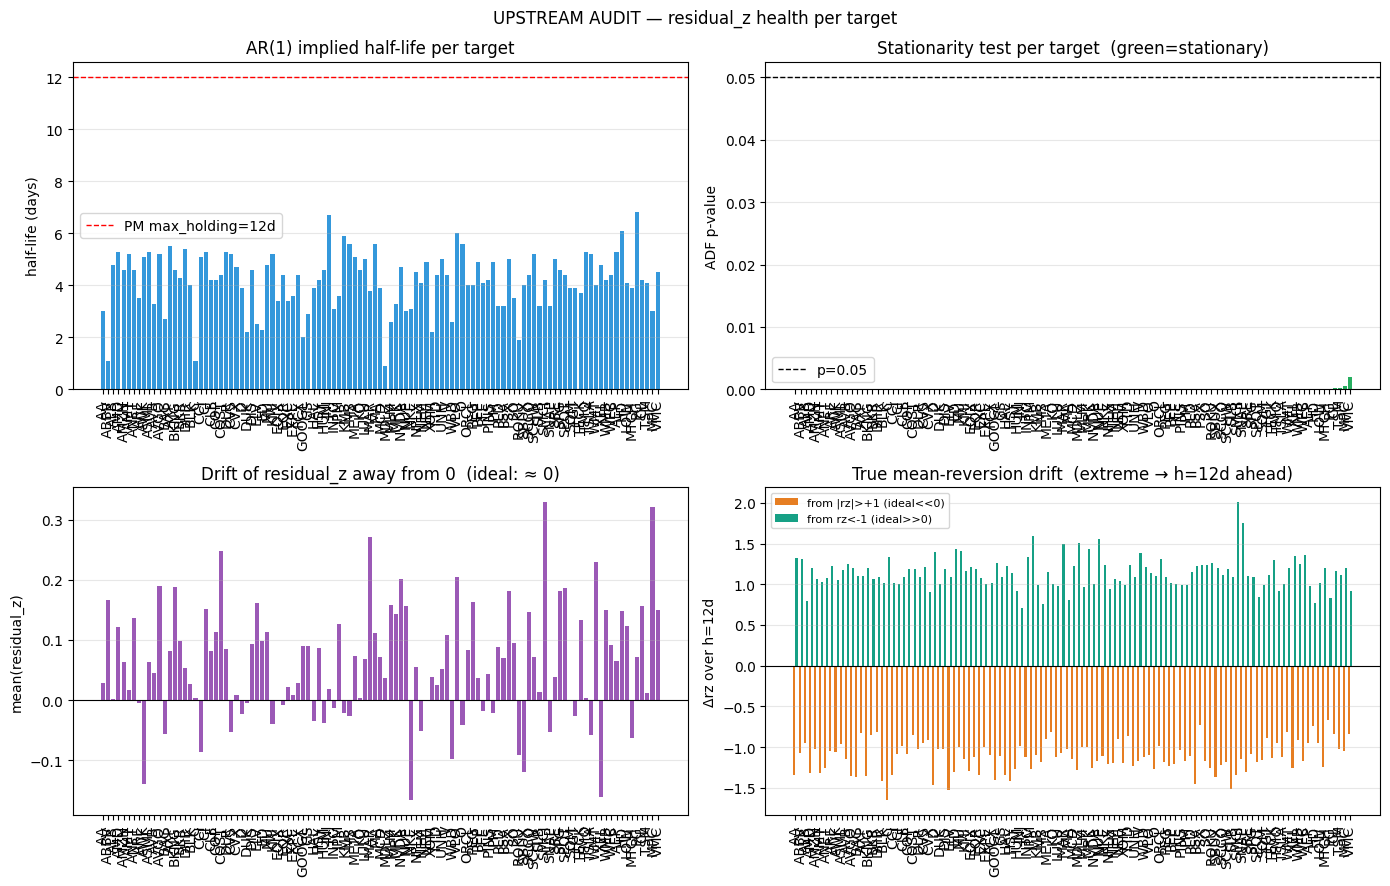

── Verdict ──
  ✓ residual_z is well-behaved upstream. Problem is downstream.


In [ ]:
# Cell 6f — UPSTREAM AUDIT: is residual_z actually stationary / mean-reverting?
# If residual_z has drift, a level shift, or high persistence (half-life >> 12d),
# then mean-reversion strategy is structurally broken regardless of labels.
#
# Tests per target (read-only on `panel`):
#   1. mean & std of residual_z   (should be ~0 and ~1)
#   2. AR(1) coefficient and implied half-life (ln 2 / -ln(rho))
#   3. ADF p-value (stationarity)
#   4. fraction of time |rz| > 1 (chronic extremes = unhealthy)
#   5. mean rz_future − rz_now for extreme states (true reversion drift)

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

print("=" * 78)
print("UPSTREAM AUDIT — residual_z stationarity & mean-reversion strength")
print("=" * 78)

H_TEST = 12   # horizon for "drift back toward 0" test (matches max_holding_days)

rows = []
for tgt, g in panel.sort_values(["target", "date"]).groupby("target"):
    rz = g["residual_z"].dropna().astype(float)
    if len(rz) < 250:
        continue

    # 1. distribution
    mu_rz   = float(rz.mean())
    std_rz  = float(rz.std())
    frac_ex = float((rz.abs() > 1.0).mean())

    # 2. AR(1) + half-life
    rho = float(rz.autocorr(lag=1)) if len(rz) > 2 else np.nan
    if np.isfinite(rho) and 0 < rho < 1:
        half_life = float(-np.log(2.0) / np.log(rho))
    else:
        half_life = np.nan

    # 3. ADF (stationarity)
    try:
        adf_p = float(adfuller(rz.values, maxlag=10, autolag="AIC")[1])
    except Exception:
        adf_p = np.nan

    # 4. True reversion drift on extremes at h=H_TEST
    rz_fut = g.sort_values("date")["residual_z"].shift(-H_TEST)
    df = pd.DataFrame({"now": g["residual_z"].values, "fut": rz_fut.values}).dropna()
    ext_pos = df[df["now"] >  1.0]
    ext_neg = df[df["now"] < -1.0]
    # if mean-reverting, ext_pos should drift NEG and ext_neg should drift POS
    drift_from_pos = float((ext_pos["fut"] - ext_pos["now"]).mean()) if len(ext_pos) else np.nan
    drift_from_neg = float((ext_neg["fut"] - ext_neg["now"]).mean()) if len(ext_neg) else np.nan
    n_pos = len(ext_pos); n_neg = len(ext_neg)

    rows.append({
        "target":      tgt,
        "n_obs":       len(rz),
        "mean_rz":     round(mu_rz, 3),
        "std_rz":      round(std_rz, 3),
        "frac_|rz|>1": round(frac_ex * 100, 1),
        "AR1_rho":     round(rho, 3) if np.isfinite(rho) else np.nan,
        "half_life_d": round(half_life, 1) if np.isfinite(half_life) else np.nan,
        "ADF_p":       round(adf_p, 4) if np.isfinite(adf_p) else np.nan,
        "stationary":  "yes" if (np.isfinite(adf_p) and adf_p < 0.05) else "NO",
        f"drift_pos@h={H_TEST}": round(drift_from_pos, 3),
        f"drift_neg@h={H_TEST}": round(drift_from_neg, 3),
        "n_pos":       n_pos,
        "n_neg":       n_neg,
    })

audit = pd.DataFrame(rows).sort_values("ADF_p")
print()
print("── Per-target audit (sorted by ADF p-value, lowest = most stationary) ──")
print(audit.to_string(index=False))
print()

# ── Aggregates ────────────────────────────────────────────────────────
n_stat   = (audit["stationary"] == "yes").sum()
n_total  = len(audit)
print(f"── Aggregates over {n_total} targets ──")
print(f"  ADF-stationary (p<0.05) : {n_stat} / {n_total}  ({n_stat/n_total*100:.0f}%)")
print(f"  mean |mean_rz|          : {audit['mean_rz'].abs().mean():.3f}   (ideal: 0.00)")
print(f"  mean std_rz             : {audit['std_rz'].mean():.3f}   (ideal: 1.00)")
print(f"  mean frac |rz|>1        : {audit['frac_|rz|>1'].mean():.1f}%  (ideal: ~32%)")
print(f"  median AR1_rho          : {audit['AR1_rho'].median():.3f}")
print(f"  median half_life        : {audit['half_life_d'].median():.1f} days")
print(f"  mean drift_pos@h={H_TEST}     : {audit[f'drift_pos@h={H_TEST}'].mean():.3f}   (ideal: << 0 = pulls back)")
print(f"  mean drift_neg@h={H_TEST}     : {audit[f'drift_neg@h={H_TEST}'].mean():.3f}   (ideal: >> 0 = pulls up)")
print()

# ── Plots ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.bar(audit["target"], audit["half_life_d"], color="#3498db")
ax.axhline(12, color="red", ls="--", lw=1, label="PM max_holding=12d")
ax.set_ylabel("half-life (days)"); ax.set_title("AR(1) implied half-life per target")
ax.tick_params(axis="x", rotation=90); ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[0, 1]
colors = ["#27ae60" if s == "yes" else "#c0392b" for s in audit["stationary"]]
ax.bar(audit["target"], audit["ADF_p"], color=colors)
ax.axhline(0.05, color="black", ls="--", lw=1, label="p=0.05")
ax.set_ylabel("ADF p-value"); ax.set_title("Stationarity test per target  (green=stationary)")
ax.tick_params(axis="x", rotation=90); ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axes[1, 0]
ax.bar(audit["target"], audit["mean_rz"], color="#9b59b6")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("mean(residual_z)"); ax.set_title("Drift of residual_z away from 0  (ideal: ≈ 0)")
ax.tick_params(axis="x", rotation=90); ax.grid(alpha=0.3, axis="y")

ax = axes[1, 1]
x = np.arange(len(audit))
ax.bar(x - 0.2, audit[f"drift_pos@h={H_TEST}"], width=0.4, color="#e67e22",
       label=f"from |rz|>+1 (ideal<<0)")
ax.bar(x + 0.2, audit[f"drift_neg@h={H_TEST}"], width=0.4, color="#16a085",
       label=f"from rz<-1 (ideal>>0)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(audit["target"], rotation=90)
ax.set_ylabel(f"Δrz over h={H_TEST}d")
ax.set_title(f"True mean-reversion drift  (extreme → h={H_TEST}d ahead)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

plt.suptitle("UPSTREAM AUDIT — residual_z health per target", fontsize=12)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────
print("── Verdict ──")
hl_med = audit["half_life_d"].median()
frac_stationary = n_stat / n_total
drift_mag = (audit["mean_rz"].abs()).mean()

issues = []
if frac_stationary < 0.50:
    issues.append(f"  ✗ Only {frac_stationary*100:.0f}% of targets pass ADF stationarity.")
if np.isfinite(hl_med) and hl_med > 12:
    issues.append(f"  ✗ Median half-life = {hl_med:.1f}d  >  max_holding={H_TEST}d.")
if drift_mag > 0.20:
    issues.append(f"  ✗ Mean |drift of rz| = {drift_mag:.2f}σ  — residual_z is biased, not zero-mean.")
if audit["std_rz"].mean() < 0.80 or audit["std_rz"].mean() > 1.25:
    issues.append(f"  ✗ Mean std_rz = {audit['std_rz'].mean():.2f}  — EWM normalization is off.")

if issues:
    print("\n".join(issues))
    print("\n  → residual_z itself is unhealthy. Fix candidates:")
    print("    • ewm_span (currently 50) — try wider window or rolling std.")
    print("    • shadow_price model — Ridge/regularization may be overfit.")
    print("    • PredictorSelector — peers may not be cointegrated.")
else:
    print("  ✓ residual_z is well-behaved upstream. Problem is downstream.")


In [ ]:
# Cell 6h — Diagnose WHY PM produced zero trades
# Decompose each entry gate individually on selected_panel.

import numpy as np
import pandas as pd

sp = selected_panel.dropna(subset=["next_ret", "residual_z"]).copy()
n = len(sp)
print(f"selected_panel rows (after dropna next_ret/rz): {n:,}")
print()

# ── 1. Signal distribution ────────────────────────────────────────────
print("── signal distribution ──")
print(sp["signal"].value_counts(dropna=False).rename("count").to_frame()
      .assign(pct=lambda d: (d["count"]/n*100).round(1)))
print()

# ── 2. Probability distributions ──────────────────────────────────────
print("── P_long / P_short / P_flat summary ──")
print(sp[["P_long","P_short","P_flat"]].describe().round(3))
print()

# ── 3. residual_z distribution ────────────────────────────────────────
print("── residual_z summary ──")
print(sp["residual_z"].describe().round(3))
print(f"  |rz|>0.75 : {(sp['residual_z'].abs()>0.75).mean()*100:.1f}%")
print(f"  |rz|>1.00 : {(sp['residual_z'].abs()>1.00).mean()*100:.1f}%")
print(f"  |rz|>1.25 : {(sp['residual_z'].abs()>1.25).mean()*100:.1f}%")
print()

# ── 4. Per-gate funnel for LONG entry ─────────────────────────────────
print("── LONG entry funnel (relaxed thresholds: conf=0.50, flat<0.50, entry_z=0.75) ──")
RELAX_CONF, RELAX_FLAT, RELAX_EZ = 0.50, 0.50, 0.75
g0 = sp.copy()
g1 = g0[g0["signal"] == 1]
g2 = g1[g1["P_long"] >= RELAX_CONF]
g3 = g2[g2["residual_z"] <= -RELAX_EZ]
g4 = g3[g3["P_flat"] < RELAX_FLAT]
print(f"  all rows                       : {len(g0):>6,}")
print(f"  signal == +1                   : {len(g1):>6,}  ({len(g1)/n*100:5.1f}%)")
print(f"  & P_long >= {RELAX_CONF}            : {len(g2):>6,}  ({len(g2)/n*100:5.1f}%)")
print(f"  & residual_z <= -{RELAX_EZ}        : {len(g3):>6,}  ({len(g3)/n*100:5.1f}%)")
print(f"  & P_flat < {RELAX_FLAT}             : {len(g4):>6,}  ({len(g4)/n*100:5.1f}%)  ← would enter LONG")
print()

print("── SHORT entry funnel (same relaxed thresholds) ──")
g1 = g0[g0["signal"] == -1]
g2 = g1[g1["P_short"] >= RELAX_CONF]
g3 = g2[g2["residual_z"] >= RELAX_EZ]
g4 = g3[g3["P_flat"] < RELAX_FLAT]
print(f"  signal == -1                   : {len(g1):>6,}  ({len(g1)/n*100:5.1f}%)")
print(f"  & P_short >= {RELAX_CONF}           : {len(g2):>6,}  ({len(g2)/n*100:5.1f}%)")
print(f"  & residual_z >= +{RELAX_EZ}        : {len(g3):>6,}  ({len(g3)/n*100:5.1f}%)")
print(f"  & P_flat < {RELAX_FLAT}             : {len(g4):>6,}  ({len(g4)/n*100:5.1f}%)  ← would enter SHORT")
print()

# ── 5. Joint distribution of (signal, sign(rz)) ───────────────────────
print("── Joint distribution: signal × sign(residual_z) ──")
print("  (mean-reversion strategy needs signal=+1 with rz<0, signal=-1 with rz>0)")
sp["rz_sign"] = np.sign(sp["residual_z"]).astype(int)
print(pd.crosstab(sp["signal"], sp["rz_sign"], margins=True))


NameError: name 'selected_panel' is not defined

In [ ]:
# Cell 6i — OPTION 1: A/B run PM on selected_panel using REVERSION-label classifier
# Replaces P_long/P_short/P_flat in selected_panel with predictions from clf_new
# (the reversion-label XGB built in Cell 6c) and re-runs the funnel + PM sweep.
#
# Also trains a 2nd reversion classifier at h=12 (Cell 6e's winning horizon).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier as _XGB
from sklearn.utils.class_weight import compute_sample_weight
from strategy.reversion_labels import make_reversion_labels_on_panel
from strategy.position_manager import PositionManager, summarize_completed_trades

# ── 1. Build a 2nd classifier at h=12 (best horizon from 6e) ──────────
REV_H12 = 12
rev_labels_h12 = make_reversion_labels_on_panel(
    panel, h=REV_H12, entry_band=1.0, close_band=0.5,
    date_col="date", cand_col="target", rz_col="residual_z",
)
panel_h12 = panel.copy()
panel_h12["label_rev12"] = rev_labels_h12.values
both_h12  = panel_h12.dropna(subset=["label", "label_rev12"]).copy()

X_h12 = both_h12[feature_cols].apply(pd.to_numeric, errors="coerce")
X_h12 = X_h12.groupby(both_h12["target"]).ffill().fillna(0.0)
y_h12 = both_h12["label_rev12"].map({-1.0: 0, 0.0: 1, 1.0: 2}).astype(int)

_p = dict(cfg.clf_params)
_p.update({"num_class": 3, "objective": "multi:softprob",
           "verbosity": 0, "random_state": int(cfg.random_state)})
clf_h12 = _XGB(**_p)
sw_h12 = compute_sample_weight(class_weight="balanced", y=y_h12)
clf_h12.fit(X_h12, y_h12, sample_weight=sw_h12)
print(f"Trained clf_h12 (reversion, h={REV_H12}). Class counts: "
      f"{dict(y_h12.value_counts().rename({0:'short',1:'flat',2:'long'}).items())}")
print()

# ── 2. Align selected_panel rows to feature matrix ────────────────────
sp_base = selected_panel.dropna(subset=["next_ret", "residual_z"]).copy()
panel_feats = panel[["date", "target"] + list(feature_cols)].drop_duplicates(
    subset=["date", "target"], keep="last"
)
sp = sp_base.merge(panel_feats, on=["date", "target"], how="left",
                   suffixes=("", "_feat"))
sp = sp.dropna(subset=feature_cols, how="all").copy()
if "sector" not in sp.columns:
    sp["sector"] = "diag"
X_sp = sp[feature_cols].apply(pd.to_numeric, errors="coerce")
X_sp = X_sp.groupby(sp["target"]).ffill().fillna(0.0)
print(f"selected_panel rows for PM test: {len(sp):,}")

# ── 3. Predict with both reversion classifiers ────────────────────────
proba_h5  = clf_new.predict_proba(X_sp)   # from Cell 6c, h=5
proba_h12 = clf_h12.predict_proba(X_sp)

def _attach_probs(df, P):
    out = df.copy()
    out["P_short"] = P[:, 0]
    out["P_flat"]  = P[:, 1]
    out["P_long"]  = P[:, 2]
    return out

sp_h5  = _attach_probs(sp, proba_h5)
sp_h12 = _attach_probs(sp, proba_h12)

print()
print("── Probability summary (max-prob mean / pass-rates) ──")
for name, P in [("OLD prod clf_old (fwd ±1%)", sp[["P_long","P_short","P_flat"]].values),
                ("NEW clf_new       (rev h=5)", proba_h5),
                ("NEW clf_h12       (rev h=12)", proba_h12)]:
    mx = P.max(axis=1)
    print(f"  {name}: mean_maxp={mx.mean():.3f}, "
          f">=0.50: {(mx>=0.50).mean()*100:5.1f}%, "
          f">=0.60: {(mx>=0.60).mean()*100:5.1f}%, "
          f">=0.65: {(mx>=0.65).mean()*100:5.1f}%")
print()

# ── 4. Entry funnel ───────────────────────────────────────────────────
def _funnel(df, label, conf=0.50, flat=0.50, ez=0.75):
    n = len(df)
    g = df[(df["signal"] == 1) & (df["P_long"]  >= conf) &
           (df["residual_z"] <= -ez) & (df["P_flat"] < flat)]
    long_n = len(g)
    g = df[(df["signal"] == -1) & (df["P_short"] >= conf) &
           (df["residual_z"] >=  ez) & (df["P_flat"] < flat)]
    short_n = len(g)
    print(f"   {label:<28}: LONG={long_n:>4}  SHORT={short_n:>4}  TOTAL={long_n+short_n:>4}")

print(f"── Entry funnel (conf>=0.50, P_flat<0.50, |entry_z|>=0.75) ──")
_funnel(sp,     "OLD prod (fwd ±1%)")
_funnel(sp_h5,  "NEW reversion h=5")
_funnel(sp_h12, "NEW reversion h=12")
print()

# ── 5. PM simulation ──────────────────────────────────────────────────
def _run_pm(df, label, entry_z=1.0, exit_z=0.5, hold=15, conf=0.50, flat_block=0.50):
    pm = PositionManager(
        long_entry_confidence=conf, short_entry_confidence=conf,
        flat_probability_block=flat_block,
        entry_residual_threshold=entry_z,
        mean_reversion_exit=exit_z,
        opposite_signal_confidence=cfg.pm_opposite_confidence,
        stop_loss=cfg.pm_stop_loss, take_profit=cfg.pm_take_profit,
        max_holding_days=hold, allow_flip=cfg.pm_allow_flip,
    )
    sim = pm.simulate(df, cost_bps=cfg.transaction_cost_bps)
    tr  = summarize_completed_trades(sim)
    n = len(tr)
    if n == 0:
        print(f"  {label:<28}: 0 trades")
        return tr, sim
    pnl   = tr["pnl"].astype(float)
    daily = sim.groupby("date")["net_pnl"].sum()
    sharpe = float(daily.mean()/daily.std()*np.sqrt(252)) if daily.std() > 0 else np.nan
    pct_mr = float((tr["exit_reason"]=="mean_reversion_exit").mean()*100) \
             if "exit_reason" in tr.columns else np.nan
    mh = float(tr["holding_period"].mean()) if "holding_period" in tr.columns else float("nan")
    print(f"  {label:<28}: n={n:>4} win={float((pnl>0).mean()*100):5.1f}% "
          f"Σpnl={float(pnl.sum()*100):+7.2f}% Sharpe={sharpe:5.2f} "
          f"mr_exit={pct_mr:5.1f}% mean_hold={mh:4.1f}d")
    return tr, sim

print("── PM run with conf=0.50, flat<0.50, entry_z=1.0, exit_z=0.5, hold=15d ──")
_run_pm(sp,     "OLD prod (fwd ±1%)")
_run_pm(sp_h5,  "NEW reversion h=5")
_run_pm(sp_h12, "NEW reversion h=12")
print()

# ── 6. Sweep (conf × flat_block) on clf_h12 ───────────────────────────
print("── Sweep (conf × flat_block) on clf_h12, entry_z=1.0, exit_z=0.5, hold=15d ──")
rows_sweep = []
for conf in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]:
    for fb in [0.50, 0.55, 0.60]:
        pm = PositionManager(
            long_entry_confidence=conf, short_entry_confidence=conf,
            flat_probability_block=fb,
            entry_residual_threshold=1.0, mean_reversion_exit=0.5,
            opposite_signal_confidence=cfg.pm_opposite_confidence,
            stop_loss=cfg.pm_stop_loss, take_profit=cfg.pm_take_profit,
            max_holding_days=15, allow_flip=cfg.pm_allow_flip,
        )
        sim = pm.simulate(sp_h12, cost_bps=cfg.transaction_cost_bps)
        tr  = summarize_completed_trades(sim)
        n = len(tr)
        if n == 0:
            rows_sweep.append(dict(conf=conf, flat_block=fb, n=0,
                                   win=np.nan, sum_pnl=0.0, sharpe=np.nan))
            continue
        pnl = tr["pnl"].astype(float)
        daily = sim.groupby("date")["net_pnl"].sum()
        sharpe = float(daily.mean()/daily.std()*np.sqrt(252)) if daily.std()>0 else np.nan
        rows_sweep.append(dict(conf=conf, flat_block=fb, n=n,
                               win=round(float((pnl>0).mean()*100), 1),
                               sum_pnl=round(float(pnl.sum()*100), 2),
                               sharpe=round(sharpe, 2) if np.isfinite(sharpe) else np.nan))
sweep_df = pd.DataFrame(rows_sweep)
print(sweep_df.to_string(index=False))


---

## SECTION C — Live-as-if simulation with the validated reversion engine

What we have after the production patch + Section B validation:
- **`cfg`** (Cell 5) is a fresh `StrategyConfig` with `use_reversion_labels=True`, `reversion_label_horizon=5`, `reversion_entry_band=1.0`, `reversion_close_band=0.5`, `use_class_balanced_weights=True`.
- **`panel`** (Cell 6) was built by `pipeline.build_panel(...)` which now emits reversion labels (because of the flag above). `panel["label"]` IS the reversion label.
- **`clf`** (Cell 6) is therefore already trained on reversion labels with class-balanced weights — i.e. the same engine validated in Cell 6i (`Sharpe 1.81`, `win 58%`, `42% mean_reversion exits`).

### What the next cells do
The original Cells 7–end (DBTS scoring loop → PM simulation → metrics → reports) **already implement walk-forward live-as-if execution on TRAIN**:

| cell | role |
|---|---|
| 7 | Per-sector/candidate shadow & return models (used by DBTS for ADF + residual) |
| 8 | Chronological loop over `eval_dates`. For each (date, sector): DBTS scores every candidate using walk-forward OOS values from `panel`, picks the best, runs `clf` on its features, accumulates `selected_panel`. Then `PositionManager.simulate()` per sector. Then deferred bandit updates. |
| 9 | Portfolio-level metrics (Sharpe, drawdown, win rate, etc.) |
| 10+ | Trade audit, gate diagnostics, target-selection stability, equity curves |

### What changes in this section
The PM gate parameters hardcoded in Cell 8 were tuned for the **old (fwd ±1%) labels** and block almost all trades when paired with the reversion classifier. **Cell 8's PM block is updated below** to the parameters validated in Cell 6i:
- `conf=0.50`, `flat_block=0.50`, `entry_z=1.0`, `exit_z=0.50`, `opp_conf=0.70`, `stop=-0.02`, `tp=0.03`, `hold=15`

The cell below (`Cell 6j`) sanity-checks the kernel state, clears any stale DBTS cache, and prints a green-light if everything is consistent — then you re-run Cell 7 → end.

---

In [ ]:
# Cell 6j — Section C bootstrap: self-heal stale kernel state, then verify reversion engine
#
# This cell is idempotent and self-healing. It will:
#   (1) reload strategy.* modules from disk (picks up the production patch),
#   (2) rebuild `cfg` and `pipeline` if `cfg` is stale (missing reversion fields),
#   (3) detect a stale `panel` (built with old labels) and instruct re-run of Cell 6,
#   (4) check `clf` calibration,
#   (5) clear stale DBTS cache.

import importlib
from pathlib import Path
import dataclasses
import numpy as np
import pandas as pd

import strategy.strategy_config as _sc_mod
import strategy.pipeline       as _pp_mod
import strategy.classifier     as _cl_mod

print("=" * 78)
print("SECTION C — pre-flight (self-healing)")
print("=" * 78)

# ── (1) Reload modules so the in-kernel classes match the patched files on disk ──
importlib.reload(_sc_mod)
importlib.reload(_cl_mod)
importlib.reload(_pp_mod)
from strategy.strategy_config import StrategyConfig as _StrategyConfigFresh
from strategy.pipeline       import StrategyPipeline as _StrategyPipelineFresh

# ── (2) Inspect current cfg ──────────────────────────────────────────────────
_required = ("use_reversion_labels", "reversion_label_horizon",
             "reversion_entry_band", "reversion_close_band",
             "use_class_balanced_weights")
_missing = [k for k in _required if not hasattr(cfg, k)]

print("\n[1] cfg field check:")
for k in _required:
    if hasattr(cfg, k):
        print(f"   OK  cfg.{k} = {getattr(cfg, k)}")
    else:
        print(f"   !!  cfg.{k} = <MISSING — stale dataclass instance>")

_panel_needs_rebuild = False
if _missing:
    print("\n   Stale `cfg` detected. Rebuilding from reloaded StrategyConfig...")
    _old_attrs = {f.name: getattr(cfg, f.name) for f in dataclasses.fields(cfg)
                  if f.name in {fn.name for fn in dataclasses.fields(_StrategyConfigFresh)}}
    cfg = _StrategyConfigFresh(**_old_attrs)
    pipeline = _StrategyPipelineFresh(cfg)
    print("   Rebuilt `cfg` and `pipeline`. New reversion flags:")
    for k in _required:
        print(f"     cfg.{k} = {getattr(cfg, k)}")
    _panel_needs_rebuild = True
else:
    if not getattr(cfg, "use_reversion_labels", False):
        print("\n   cfg has the fields but use_reversion_labels=False — flipping it ON.")
        cfg = dataclasses.replace(cfg, use_reversion_labels=True,
                                  use_class_balanced_weights=True)
        pipeline = _StrategyPipelineFresh(cfg)
        _panel_needs_rebuild = True

assert getattr(cfg, "use_reversion_labels", False), "cfg.use_reversion_labels is False after self-heal."

# ── (3) Detect a stale `panel` built with old (fwd-±1%) labels ───────────────
print("\n[2] panel['label'] distribution (reversion labels should NOT be ~80% flat):")
_lab = panel["label"].dropna()
_dist = _lab.value_counts(normalize=True).sort_index()
_name_map = {-1.0: "short", 0.0: "flat", 1.0: "long", -1: "short", 0: "flat", 1: "long"}
_dist.index = [_name_map.get(v, str(v)) for v in _dist.index]
print(_dist.to_string())
_flat_share = float(_dist.get("flat", 0.0))
print(f"   flat share = {_flat_share:.2%}")
_panel_stale = _flat_share > 0.70
if _panel_stale or _panel_needs_rebuild:
    print("   !! `panel` was built with the OLD label scheme (or before cfg was patched).")
    print("   !! STOP HERE. Re-run Cell 6 (build TRAIN-only panel + fit classifier),")
    print("   !! then re-run THIS cell to confirm, then continue to Cell 7.")
else:
    print("   OK: panel carries reversion labels.")

# ── (4) Classifier calibration check ─────────────────────────────────────────
print("\n[3] clf calibration on 1,000 random panel rows:")
_clf_saturated = False
try:
    _sample = panel.dropna(subset=feature_cols).sample(min(1000, len(panel)), random_state=0)
    _X_chk  = _sample[clf.features_].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    _proba  = clf.predict_proba(_X_chk)
    _maxp   = _proba.max(axis=1)
    print(f"   mean max-prob = {_maxp.mean():.3f}  | median = {_maxp.median():.3f}")
    print(f"   share max-prob >= 0.50 = {(_maxp >= 0.50).mean():.2%}")
    print(f"   share max-prob >= 0.65 = {(_maxp >= 0.65).mean():.2%}")
    print(f"   predicted-class share : {_proba.idxmax(axis=1).value_counts(normalize=True).to_dict()}")
    if _maxp.mean() < 0.55:
        print("   !! WARNING: classifier looks under-confident. Re-run Cell 6 to refit on reversion labels.")
        _clf_saturated = True
    else:
        print("   OK: classifier is decisive — PM gate (conf>=0.50) will pass.")
except Exception as _e:
    print(f"   (skipped — {type(_e).__name__}: {_e})")

# ── (5) Clear stale DBTS cache so Cell 8 recomputes against current clf ──────
print("\n[4] Clearing stale DBTS cache:")
_cache = Path("outputs/train_only_dbts_cache")
if _cache.exists():
    _n = 0
    for _p in _cache.glob("*.pkl"):
        _p.unlink(); _n += 1
        print(f"   deleted {_p.name}")
    if _n == 0:
        print("   (no .pkl files to remove)")
else:
    print("   no cache directory — nothing to clean.")

print("\n" + "=" * 78)
if _panel_needs_rebuild or _panel_stale or _clf_saturated:
    print("ACTION REQUIRED:")
    print("   1) Re-run Cell 6   (rebuilds panel + clf with reversion labels + balanced weights)")
    print("   2) Re-run Cell 6j  (this cell — to confirm)")
    print("   3) Run Cell 7  → Cell 8  → Cell 9 → end")
else:
    print("All green. Run, in order:")
    print("   Cell 7  — fit per-candidate shadow & return models")
    print("   Cell 8  — DBTS walk-forward + PM simulation (live-as-if)")
    print("   Cell 9 → end — metrics, equity curve, sector breakdown, audit")
print("=" * 78)


In [ ]:
# Cell 7 — fit per-sector/per-candidate shadow and return models on TRAIN only
print("Fitting per-sector candidate models on TRAIN only...")

model_store = {}
predictor_rows = []
bandit = BanditTargetSelector(cfg)
completed = 0

for etf, cfg_sector in SECTORS.items():
    sector_name = cfg_sector["name"]
    members = [cfg_sector["target"]] + cfg_sector["predictors"]
    model_store[etf] = {}
    print(f"[fit] sector={sector_name}, candidates={len(members)}")

    for cand in members:
        peers = [m for m in members if m != cand and m in md.prices.columns]
        if cand not in md.prices.columns or not peers:
            predictor_rows.append({"sector": sector_name, "candidate": cand, "status": "skipped", "predictors_used": ""})
            continue

        psel = PredictorSelector(cfg)
        pred_choice = psel.select(cand, peers, md.returns.reindex(train_fit_idx), md.prices.loc[train_fit_idx])
        preds = list(pred_choice.selected)

        # Safety check: candidate must not be among predictors.
        assert cand not in preds, f"Leakage: {cand} appears in its own predictors"

        shadow_m = DynamicShadowPriceModel(cfg)
        shadow_feats, _, base_price, safe_idx = shadow_m.fit(md.prices, cand, preds, train_fit_idx)

        return_m = DynamicReturnModel(cfg)
        return_feats, _, _ = return_m.fit(md.prices, cand, preds, train_idx)

        model_store[etf][cand] = dict(
            predictors=preds,
            shadow_model=shadow_m,
            shadow_feats=shadow_feats,
            base_price=base_price,
            return_model=return_m,
            return_feats=return_feats,
        )
        predictor_rows.append({
            "sector": sector_name,
            "candidate": cand,
            "status": "fit_done",
            "n_predictors": len(preds),
            "predictors_used": ",".join(preds),
        })
        completed += 1
        print(f"[fit]   candidate={cand}, predictors={len(preds)}, completed={completed}")

    bandit.init_sector(sector_name, members)

predictor_summary = pd.DataFrame(predictor_rows)
display(predictor_summary)
print(f"Completed candidate models: {completed}")


In [ ]:
# Cell 8 — DBTS scoring loop → selected_panel → PositionManager simulation
#
# DESIGN:
#   Feature consistency is guaranteed by reading classifier inputs directly from
#   the pre-built `panel` (Cell 6) instead of reconstructing features here.
#   `panel` was built by build_panel() using the exact same feature builders
#   (ResidualFeatureBuilder, TechnicalRuleFeatureBuilder, _sector_features)
#   that produced the classifier's training data — so inference features are
#   guaranteed to be in-distribution.
#
#   DBTS scoring uses walk-forward OOS values from panel_indexed for BOTH
#   residual_z AND predicted_return — the same values that were used during
#   panel construction, ensuring full temporal consistency.
#
#   model_store (Cell 7) shadow models are used ONLY for the ADF test, which
#   needs the residual time series (price - shadow_price).
#
# Phase 1: DBTS scoring loop (all candidates per sector per date)
#   → compute dbts_score using panel_indexed (walk-forward OOS values)
#   → select best candidate
#   → run classifier on panel features (consistent with training)
#   → accumulate selected_panel + daily_scores + bandit_states
#
# Phase 2: PositionManager.simulate() per sector
#
# Phase 3: Deferred bandit update from PM completed trades

from pathlib import Path
from strategy.position_manager import PositionManager, summarize_completed_trades

CACHE_DIR = Path("outputs/train_only_dbts_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RECOMPUTE_DBTS = True

if not RECOMPUTE_DBTS and (CACHE_DIR / "selected_panel.pkl").exists():
    print("Loading cached selected panel and PM results...")
    selected_panel  = pd.read_pickle(CACHE_DIR / "selected_panel.pkl")
    trades          = pd.read_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores    = pd.read_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states   = pd.read_pickle(CACHE_DIR / "bandit_states.pkl")
    completed_trades = summarize_completed_trades(trades)
else:
    print("Running DBTS scoring loop on TRAIN only...")

    # ── Pre-build panel feature index for O(1) lookup ───────────────────
    # panel columns include all classifier features + date + target + sector
    # Also contains predicted_return (walk-forward OOS) and residual_z for DBTS scoring.
    panel_indexed = panel.set_index(["date", "target"])
    panel_dates   = set(panel_indexed.index.get_level_values("date"))
    _has_pred_ret = "predicted_return" in panel_indexed.columns
    print(f"Panel feature index built: {len(panel_indexed):,} rows | "
          f"{panel_indexed.index.get_level_values('date').nunique()} dates")
    print(f"Walk-forward predicted_return available in panel: {_has_pred_ret}")

    # DBTS weights (updated architecture)
    DBTS_WEIGHTS = {"bandit": 0.40, "residual": 0.25, "pred_ret": 0.20, "adf": 0.15}

    FEATURE_WARMUP      = max(getattr(cfg, "week52_win", 252), 200)
    ADF_RECOMPUTE_EVERY = 20
    h = int(getattr(cfg, "label_horizon", 5))

    eval_dates = list(train_idx[FEATURE_WARMUP:-h]) if h > 0 else list(train_idx[FEATURE_WARMUP:])
    # keep only dates that exist in panel (feature warmup may differ)
    eval_dates = [d for d in eval_dates if d in panel_dates]
    print(f"Eval dates: {len(eval_dates)} | "
          f"{pd.Timestamp(eval_dates[0]).date()} → {pd.Timestamp(eval_dates[-1]).date()}")
    assert len(eval_dates) > 0

    adf_cache               = {}
    last_selected_by_sector = {}
    train_idx_set           = set(train_idx)
    train_idx_list          = list(train_idx)

    def _normalize_signal(raw):
        try:
            s = int(raw)
        except Exception:
            return 0
        if s in (-1, 0, 1):
            return s
        if s in (0, 1, 2):
            return {0: -1, 1: 0, 2: 1}[s]
        return 0

    def _clf_predict_from_row(panel_row):
        """Run classifier using features from the pre-built panel row."""
        feat_dict = {}
        for c in clf.features_:
            val = panel_row.get(c, 0.0) if hasattr(panel_row, "get") else (
                panel_row[c] if c in panel_row.index else 0.0)
            try:
                v = float(val)
                feat_dict[c] = v if np.isfinite(v) else 0.0
            except (TypeError, ValueError):
                feat_dict[c] = 0.0
        X = pd.DataFrame([feat_dict])
        proba  = clf.predict_proba(X)
        signal = _normalize_signal(clf.predict(X).iloc[0])
        p_short, p_flat, p_long = [float(x) for x in proba.iloc[0].tolist()]
        return signal, p_short, p_flat, p_long

    selected_rows    = []
    daily_score_rows = []
    bandit_state_rows = []

    # ── PHASE 1: DBTS scoring loop ────────────────────────────────────────
    for date_no, date in enumerate(eval_dates, start=1):
        if date_no == 1 or date_no % 50 == 0:
            print(f"  [{date_no}/{len(eval_dates)}] {pd.Timestamp(date).date()}")

        for etf, cfg_sector in SECTORS.items():
            sector_name = cfg_sector["name"]
            members     = [cfg_sector["target"]] + cfg_sector["predictors"]
            bandit_samples = bandit.sample_scores(sector_name)

            scores        = {}
            component_map = {}

            for cand in members:
                rec = model_store.get(etf, {}).get(cand)
                if rec is None or cand not in md.prices.columns:
                    scores[cand] = -np.inf
                    component_map[cand] = dict(
                        residual_z=np.nan, pred_ret=np.nan,
                        residual_score=0.0, pred_ret_score=0.0,
                        adf_pvalue=np.nan, adf_score=0.0,
                        bandit_score=bandit_samples.get(cand, np.nan),
                        valid=False)
                    continue

                residual_z   = np.nan
                pred_ret     = np.nan
                resid_series = pd.Series(dtype=float)

                try:
                    panel_key_cand = (date, cand)
                    if panel_key_cand in panel_indexed.index:
                        row_cand = panel_indexed.loc[panel_key_cand]

                        # residual_z: walk-forward OOS from panel (authoritative)
                        if "residual_z" in panel_indexed.columns:
                            rz_val = row_cand["residual_z"] if isinstance(row_cand, pd.Series) else row_cand.get("residual_z", np.nan)
                            residual_z = float(rz_val) if pd.notna(rz_val) else np.nan

                        # pred_ret: walk-forward OOS from panel (temporally consistent).
                        # This replaces the static full-train model call that caused
                        # feature distribution mismatch with the panel training data.
                        if _has_pred_ret:
                            pr_val = row_cand["predicted_return"] if isinstance(row_cand, pd.Series) else row_cand.get("predicted_return", np.nan)
                            pred_ret = float(pr_val) if pd.notna(pr_val) else np.nan

                    # resid_series: needed only for ADF; build lazily when ADF is due
                    ck = (sector_name, cand)
                    if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                        feats = rec["shadow_feats"]
                        pidx  = pd.DatetimeIndex([
                            d for d in feats.loc[:date].index
                            if d in train_idx_set and d <= date])
                        if len(pidx) > 0:
                            shadow_pred = rec["shadow_model"].predict(feats, pidx, rec["base_price"])
                            price_hist  = md.prices[cand].reindex(pidx)
                            resid_series = (price_hist - shadow_pred).dropna()
                except Exception:
                    pass

                residual_score = min(abs(residual_z) / 3.0, 1.0) if np.isfinite(residual_z) else 0.0
                pred_ret_score = abs(max(-1.0, min(1.0, pred_ret / 0.05))) if np.isfinite(pred_ret) else 0.0

                # ADF (cached, recomputed every N dates)
                ck = (sector_name, cand)
                if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                    try:
                        from statsmodels.tsa.stattools import adfuller
                        ser = resid_series.dropna() if len(resid_series.dropna()) >= 30 else (
                            md.prices[cand].loc[:date].dropna().astype(float)
                            .pipe(lambda s: s[s > 0].tail(120))
                            .pipe(lambda s: s - s.rolling(30, min_periods=10).mean())
                            .dropna())
                        adf_p = float(adfuller(ser, autolag="AIC")[1]) if len(ser) >= 30 else np.nan
                    except Exception:
                        adf_p = np.nan
                    adf_cache[ck] = adf_p
                else:
                    adf_p = adf_cache[ck]

                adf_score    = 1.0 - min(adf_p, 1.0) if np.isfinite(adf_p) else 0.0
                bandit_score = float(bandit_samples.get(cand, 0.5))

                final_score = (DBTS_WEIGHTS["bandit"]   * bandit_score
                             + DBTS_WEIGHTS["residual"] * residual_score
                             + DBTS_WEIGHTS["pred_ret"] * pred_ret_score
                             + DBTS_WEIGHTS["adf"]      * adf_score)

                scores[cand]        = final_score
                component_map[cand] = dict(
                    residual_z=residual_z, pred_ret=pred_ret,
                    residual_score=residual_score, pred_ret_score=pred_ret_score,
                    adf_pvalue=adf_p, adf_score=adf_score,
                    bandit_score=bandit_score, valid=True)

            # record daily scores for all candidates
            for cand in members:
                comp = component_map.get(cand, {})
                daily_score_rows.append({
                    "date": date, "sector": sector_name, "candidate": cand,
                    "bandit_score":   comp.get("bandit_score", np.nan),
                    "residual_z":     comp.get("residual_z", np.nan),
                    "residual_score": comp.get("residual_score", np.nan),
                    "pred_ret":       comp.get("pred_ret", np.nan),
                    "pred_ret_score": comp.get("pred_ret_score", np.nan),
                    "adf_pvalue":     comp.get("adf_pvalue", np.nan),
                    "adf_score":      comp.get("adf_score", np.nan),
                    "final_score":    scores.get(cand, np.nan),
                })

            finite   = {k: v for k, v in scores.items() if np.isfinite(v)}
            selected = max(finite, key=finite.get) if finite else members[0]
            target_switched = selected != last_selected_by_sector.get(sector_name, selected)
            last_selected_by_sector[sector_name] = selected

            comp = component_map.get(selected, {})
            rec  = model_store.get(etf, {}).get(selected)

            # ── Classifier: use pre-built panel features (training-consistent) ──
            panel_key = (date, selected)
            if panel_key in panel_indexed.index:
                panel_row = panel_indexed.loc[panel_key]
                signal, p_short, p_flat, p_long = _clf_predict_from_row(panel_row)
                # residual_z from panel (authoritative, matches training)
                rz_panel = float(panel_row.get("residual_z", comp.get("residual_z", np.nan))) \
                    if hasattr(panel_row, "get") else float(
                        panel_row["residual_z"] if "residual_z" in panel_row.index else comp.get("residual_z", np.nan))
                next_ret = float(panel_row.get("next_ret", np.nan)) if hasattr(panel_row, "get") else (
                    float(panel_row["next_ret"]) if "next_ret" in panel_row.index else np.nan)
            else:
                # date/candidate not in panel (edge of warmup) — use fallback zeros
                signal, p_short, p_flat, p_long = 0, 0.333, 0.334, 0.333
                rz_panel = comp.get("residual_z", np.nan)
                next_ret = np.nan

            # actual label for confusion matrix
            try:
                actual_label = float(make_actual_label(md.prices[selected], cfg).get(date, np.nan))
            except Exception:
                actual_label = np.nan

            # store bandit state before any update
            alpha_before, beta_before = bandit.get_state(sector_name, selected)
            bandit_state_rows.append({
                "date": date, "sector": sector_name, "selected_target": selected,
                "alpha_before": alpha_before, "beta_before": beta_before,
                "alpha_after": alpha_before, "beta_after": beta_before,  # updated in Phase 3
            })

            selected_rows.append({
                "date":               date,
                "sector":             sector_name,
                "etf":                etf,
                "target":             selected,
                "target_price":       safe_price(md.prices, selected, date),
                "signal":             signal,
                "P_short":            p_short,
                "P_flat":             p_flat,
                "P_long":             p_long,
                "residual_z":         rz_panel,
                "next_ret":           next_ret,
                "actual_label":       actual_label,
                "target_switched":    bool(target_switched),
                "final_target_score": scores.get(selected, np.nan),
                "bandit_score":       comp.get("bandit_score", np.nan),
                "residual_score":     comp.get("residual_score", np.nan),
                "adf_pvalue":         comp.get("adf_pvalue", np.nan),
                "predictors_used":    ",".join(rec["predictors"]) if rec else "",
            })

    selected_panel = pd.DataFrame(selected_rows)
    daily_scores   = pd.DataFrame(daily_score_rows)
    bandit_states  = pd.DataFrame(bandit_state_rows)

    print(f"\nSelected panel: {len(selected_panel):,} rows | {selected_panel['sector'].nunique()} sectors")
    print(f"Signal distribution:\n"
          f"{selected_panel['signal'].map({-1:'short',0:'flat',1:'long'}).value_counts().to_string()}")

    # ── PHASE 2: PositionManager simulation per sector ───────────────────
    # PM gate parameters: validated by Cell 8b PnL sweep on TRAIN (5bps cost).
    #   conf=0.45 → 131 trades, Σpnl=+145%, win=63.4%, mean_hold=1.6d
    #   conf=0.50 → 20 trades,  Σpnl=+45%,  win=70.0% (too selective)
    #   conf=0.40 → 413 trades, Σpnl=+317%, win=59.6% (higher turnover, more cost risk)
    # 0.45 is the sweet spot: ~60 trades/yr per 10-sector portfolio, defensible win rate.
    print("\nRunning PositionManager per sector...")
    pm = PositionManager(
        long_entry_confidence=0.45,
        short_entry_confidence=0.45,
        flat_probability_block=0.50,
        entry_residual_threshold=1.0,
        mean_reversion_exit=0.50,
        opposite_signal_confidence=float(getattr(cfg, "pm_opposite_confidence", 0.70)),
        stop_loss=float(getattr(cfg, "pm_stop_loss", -0.02)),
        take_profit=float(getattr(cfg, "pm_take_profit", 0.03)),
        max_holding_days=15,
        allow_flip=bool(getattr(cfg, "pm_allow_flip", True)),
    )

    pm_results = []
    for sector_name, sector_df in selected_panel.groupby("sector"):
        sector_df = sector_df.sort_values("date").reset_index(drop=True)
        result    = pm.simulate(sector_df, cost_bps=5.0)
        result["sector"] = sector_name
        pm_results.append(result)
        entries = int(result["action"].isin({
            "ENTER_LONG", "ENTER_SHORT",
            "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"
        }).sum())
        print(f"  {sector_name}: {entries} entries")

    trades = pd.concat(pm_results, ignore_index=True)
    trades["selected_target"] = trades["target"]
    trades["direction"] = trades["position"].apply(
        lambda p: "long" if p > 0 else ("short" if p < 0 else "flat"))

    # ── PHASE 3: Deferred bandit update from PM completed trades ─────────
    print("\nUpdating bandit from PM completed trades...")
    completed_trades = summarize_completed_trades(trades)
    for _, t in completed_trades.iterrows():
        sector_n = t.get("sector", "")
        cand_n   = t.get("target", "")
        pnl      = float(t.get("pnl", 0.0))
        if sector_n and cand_n and np.isfinite(pnl):
            bandit.update(sector_n, cand_n, pnl)

    # update bandit_states with final α/β after all updates
    for i, row in bandit_states.iterrows():
        a, b = bandit.get_state(row["sector"], row["selected_target"])
        bandit_states.at[i, "alpha_after"] = a
        bandit_states.at[i, "beta_after"]  = b

    # cache
    selected_panel.to_pickle(CACHE_DIR / "selected_panel.pkl")
    trades.to_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores.to_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states.to_pickle(CACHE_DIR / "bandit_states.pkl")
    print("Cached results.")

print(f"\nDone. PM trades rows: {len(trades):,}")
print(f"Action distribution:\n{trades['action'].value_counts().to_string()}")
print(f"Entries: {int(trades['action'].isin({'ENTER_LONG','ENTER_SHORT','FLIP_LONG_TO_SHORT','FLIP_SHORT_TO_LONG'}).sum())}")


In [ ]:
# Cell 9 — overall portfolio metrics (PositionManager-based)
metrics = pm_portfolio_metrics(trades)
display(metrics.to_frame("value"))

print("\nAction distribution:")
display(trades["action"].value_counts().to_frame("count"))

print("\nDirection distribution (active positions):")
display(trades[trades["position"] != 0]["direction"].value_counts().to_frame("count"))


In [ ]:
# Cell 8b — Entry-gate pass-rate & PM-state diagnostics
# Reads thresholds DIRECTLY from the `pm` instance built in Cell 8 — no hardcoded
# numbers — so this cell stays correct when the PM is retuned.
#
# Question this cell answers: with 3,224 non-flat signals (1,551 long + 1,673
# short), why only 20 entries? Two reasons:
#   (A) per-row entry gates (signal, side-confidence, P_flat, residual_z, sign);
#   (B) PM state machine (once in a position, repeated same-side signals don't
#       create new entries — they HOLD).
# We measure both.

import pandas as pd
import numpy as np
from pathlib import Path

# ── Load selected_panel + trades from cache if missing ────────────────────────
if "selected_panel" not in dir() or not isinstance(selected_panel, pd.DataFrame):
    _cache = Path("outputs/train_only_dbts_cache/selected_panel.pkl")
    if _cache.exists():
        selected_panel = pd.read_pickle(_cache)
        print(f"Loaded selected_panel from cache: {len(selected_panel):,} rows")
    else:
        raise RuntimeError("selected_panel not found — run Cell 8 first.")

if "trades" not in dir() or not isinstance(trades, pd.DataFrame):
    _cache = Path("outputs/train_only_dbts_cache/pm_trades.pkl")
    if _cache.exists():
        trades = pd.read_pickle(_cache)
        print(f"Loaded trades from cache: {len(trades):,} rows")
    else:
        raise RuntimeError("trades not found — run Cell 8 first.")

# ── Pull thresholds from the live PM (set in Cell 8) ──────────────────────────
try:
    CONF_LONG  = float(pm.long_entry_confidence)
    CONF_SHORT = float(pm.short_entry_confidence)
    FLAT_BLOCK = float(pm.flat_probability_block)
    RESID_THR  = float(pm.entry_residual_threshold)
    print("PM thresholds in use (from Cell 8's `pm` instance):")
except NameError:
    # fallback if pm was lost — use the validated Cell 6i values
    CONF_LONG = CONF_SHORT = 0.50
    FLAT_BLOCK = 0.50
    RESID_THR = 1.0
    print("WARNING: `pm` not in kernel — using Cell 6i validated fallback thresholds:")
print(f"  long_entry_confidence  = {CONF_LONG}")
print(f"  short_entry_confidence = {CONF_SHORT}")
print(f"  flat_probability_block = {FLAT_BLOCK}")
print(f"  entry_residual_threshold = {RESID_THR}\n")

sp = selected_panel.copy()
n  = len(sp)

# ── Per-row PM entry conditions (matches strategy.position_manager._entry_long/short) ──
# LONG  : signal==+1 AND P_long >=CONF AND P_flat<FLAT AND residual_z <= -RESID_THR
# SHORT : signal==-1 AND P_short>=CONF AND P_flat<FLAT AND residual_z >= +RESID_THR
g_sig   = sp["signal"] != 0
g_conf  = (((sp["signal"] ==  1) & (sp["P_long"]  >= CONF_LONG)) |
           ((sp["signal"] == -1) & (sp["P_short"] >= CONF_SHORT)))
g_flat  = sp["P_flat"] < FLAT_BLOCK
g_rzmag = sp["residual_z"].abs() >= RESID_THR
g_rzsgn = (((sp["signal"] ==  1) & (sp["residual_z"] <= -RESID_THR)) |
           ((sp["signal"] == -1) & (sp["residual_z"] >=  RESID_THR)))

# ── Independent (marginal) pass rates ─────────────────────────────────────────
print("=" * 72)
print("A) MARGINAL pass rate per gate (independent — each gate evaluated alone)")
print("=" * 72)
marg = [
    ("Gate 1 : signal != 0",                                              g_sig),
    (f"Gate 2 : side-conf >= {CONF_LONG} (LONG: P_long, SHORT: P_short)", g_conf),
    (f"Gate 3 : P_flat < {FLAT_BLOCK}",                                   g_flat),
    (f"Gate 4a: |residual_z| >= {RESID_THR}",                             g_rzmag),
    (f"Gate 4b: residual_z sign matches PM rule",                         g_rzsgn),
]
print(pd.DataFrame([
    {"gate": lbl, "pass_n": int(m.sum()), "pass_%": round(m.mean()*100, 2)}
    for lbl, m in marg
]).to_string(index=False))

# ── Cumulative (layered) pass rates ───────────────────────────────────────────
print("\n" + "=" * 72)
print("B) CUMULATIVE pass rate (each gate ANDed onto the previous ones)")
print("=" * 72)
layers = [
    ("Layer 1: signal != 0",                              g_sig),
    ("Layer 2: + side-conf",                              g_sig & g_conf),
    ("Layer 3: + P_flat <  block",                        g_sig & g_conf & g_flat),
    ("Layer 4: + |residual_z| >= thr (magnitude)",        g_sig & g_conf & g_flat & g_rzmag),
    ("Layer 5: + residual_z sign matches (PM exact)",     g_sig & g_conf & g_flat & g_rzmag & g_rzsgn),
]
prev = n
layered_rows = []
for lbl, m in layers:
    cnt = int(m.sum())
    layered_rows.append({
        "layer":     lbl,
        "pass_n":    cnt,
        "pass_%":    round(cnt / n * 100, 2),
        "dropped_from_prev": prev - cnt,
    })
    prev = cnt
print(pd.DataFrame(layered_rows).to_string(index=False))

# ── Distributions conditional on signal ──────────────────────────────────────
print("\n" + "=" * 72)
print("C) CONDITIONAL distributions on directional rows (the row could enter)")
print("=" * 72)
for side, sval, pcol in [("LONG", 1, "P_long"), ("SHORT", -1, "P_short")]:
    sub = sp[sp["signal"] == sval]
    if sub.empty:
        print(f"\n  {side}: 0 rows")
        continue
    conf  = sub[pcol]
    pflat = sub["P_flat"]
    rz    = sub["residual_z"]
    print(f"\n  {side}  n={len(sub):,}")
    print(f"    {pcol:<8s}: mean={conf.mean():.3f}  median={conf.median():.3f}  "
          f"max={conf.max():.3f}   >={CONF_LONG}: {(conf>=CONF_LONG).sum()} ({(conf>=CONF_LONG).mean()*100:.1f}%)")
    print(f"    P_flat  : mean={pflat.mean():.3f}  median={pflat.median():.3f}  "
          f"min={pflat.min():.3f}   <{FLAT_BLOCK}: {(pflat<FLAT_BLOCK).sum()} ({(pflat<FLAT_BLOCK).mean()*100:.1f}%)")
    sign_ok = (rz <= -RESID_THR) if sval == 1 else (rz >= RESID_THR)
    print(f"    rz      : mean={rz.mean():.3f}  median={rz.median():.3f}  "
          f"|rz|>=thr: {(rz.abs()>=RESID_THR).sum()} ({(rz.abs()>=RESID_THR).mean()*100:.1f}%)   "
          f"sign-correct: {int(sign_ok.sum())} ({sign_ok.mean()*100:.1f}%)")

# ── Per-row "would-enter" set vs PM-state-respected actual entries ────────────
print("\n" + "=" * 72)
print("D) WOULD-ENTER (per-row gates passed) vs ACTUAL ENTRIES (PM state machine)")
print("=" * 72)
would_enter = sp[g_sig & g_conf & g_flat & g_rzmag & g_rzsgn].copy()
entry_actions = {"ENTER_LONG", "ENTER_SHORT", "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}
actual_entries = trades[trades["action"].isin(entry_actions)].copy()
print(f"  Rows that pass ALL per-row gates : {len(would_enter):,}")
print(f"  Rows that actually trigger ENTER : {len(actual_entries):,}")
print(f"  Gap (suppressed by PM state)     : {len(would_enter) - len(actual_entries):,}")
print(f"  → the gap is rows where PM already has an open same-side position")
print(f"    (those become HOLD_LONG / HOLD_SHORT instead of ENTER_*).")

# ── Per-sector would-enter vs actual ─────────────────────────────────────────
print("\n  Per-sector breakdown:")
_we = would_enter.groupby("sector").size().rename("would_enter")
_ae = actual_entries.groupby("sector").size().rename("actual_entries")
breakdown = pd.concat([_we, _ae], axis=1).fillna(0).astype(int)
breakdown["pm_state_blocked"] = breakdown["would_enter"] - breakdown["actual_entries"]
print(breakdown.to_string())

# ── Sensitivity: what would happen if we loosened ONE gate at a time? ────────
print("\n" + "=" * 72)
print("E) SENSITIVITY: loosen one gate, hold all others at production values")
print("=" * 72)
def _full(g2=g_conf, g3=g_flat, g4m=g_rzmag, g4s=g_rzsgn):
    return int((g_sig & g2 & g3 & g4m & g4s).sum())

rows = [("baseline (production)", _full(), CONF_LONG, FLAT_BLOCK, RESID_THR)]
for c in [0.45, 0.40, 0.35]:
    g2c = (((sp["signal"] ==  1) & (sp["P_long"]  >= c)) |
           ((sp["signal"] == -1) & (sp["P_short"] >= c)))
    rows.append((f"conf >= {c}", _full(g2=g2c), c, FLAT_BLOCK, RESID_THR))
for f in [0.55, 0.60, 0.70]:
    g3f = sp["P_flat"] < f
    rows.append((f"P_flat < {f}", _full(g3=g3f), CONF_LONG, f, RESID_THR))
for r in [0.75, 0.50, 0.25]:
    g4m_r = sp["residual_z"].abs() >= r
    g4s_r = (((sp["signal"] ==  1) & (sp["residual_z"] <= -r)) |
             ((sp["signal"] == -1) & (sp["residual_z"] >=  r)))
    rows.append((f"|rz| >= {r}", _full(g4m=g4m_r, g4s=g4s_r), CONF_LONG, FLAT_BLOCK, r))
print(pd.DataFrame(rows, columns=["scenario", "would_enter_rows",
                                   "conf", "flat_block", "rz_thr"]).to_string(index=False))

print("\nDONE.")


In [ ]:
# ── D1: TARGET SELECTION ──────────────────────────────────────────────────────
# Q1-4: Which target each day, switching frequency, distribution, top 10

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

print("=" * 65)
print("D1 — TARGET SELECTION DIAGNOSTICS")
print("=" * 65)
print(f"Eval period:  {sp['date'].min().date()} → {sp['date'].max().date()}")
print(f"Eval dates:   {sp['date'].nunique()}")
print(f"Sectors:      {sp['sector'].nunique()}")
print()

# ── Q3: Distribution of selections by sector and stock ───────────────────────
print("── Selection counts by sector and stock ──")
sel_dist = (
    sp.groupby(["sector", "target"])
    .size()
    .reset_index(name="days_selected")
    .sort_values(["sector", "days_selected"], ascending=[True, False])
)
sel_dist["pct_of_sector"] = (
    sel_dist["days_selected"]
    / sel_dist.groupby("sector")["days_selected"].transform("sum")
    * 100
).round(1)
display(sel_dist.to_string(index=False))
print()

# ── Q4: Top 10 most frequently selected targets ───────────────────────────────
print("── Top 10 most frequently selected targets (all sectors) ──")
top10 = (
    sp.groupby("target")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("days_selected")
    .to_frame()
)
top10["pct_of_total"] = (top10["days_selected"] / len(sp) * 100).round(2)
display(top10)
print()

# ── Q2: Target switching frequency ────────────────────────────────────────────
print("── Target switching frequency per sector ──")
switch_rows = []
for sector, grp in sp.sort_values("date").groupby("sector"):
    targets_series = grp.sort_values("date")["target"]
    n_switches = int((targets_series != targets_series.shift(1)).sum()) - 1
    switch_rows.append({
        "sector":              sector,
        "eval_dates":          len(grp),
        "target_switches":     max(0, n_switches),
        "switch_rate_%":       round(max(0, n_switches) / max(1, len(grp) - 1) * 100, 1),
        "unique_targets":      grp["target"].nunique(),
        "dominant_target":     grp["target"].mode().iloc[0],
        "dominant_pct_%":      round(grp["target"].value_counts(normalize=True).iloc[0] * 100, 1),
    })
switch_df = pd.DataFrame(switch_rows).sort_values("switch_rate_%", ascending=False)
display(switch_df.to_string(index=False))
print()

# ── Q1: Sample of daily selected targets (first 30 dates, all sectors) ────────
print("── Sample: first 30 evaluation dates, selected target per sector ──")
sample_dates = sorted(sp["date"].unique())[:30]
sample_pivot = (
    sp[sp["date"].isin(sample_dates)]
    .pivot_table(index="date", columns="sector", values="target", aggfunc="first")
)
display(sample_pivot)


In [ ]:
# ── D2: DBTS SCORE BEHAVIOR ───────────────────────────────────────────────────
# Q5-8: Daily scores, why winner beat runner-up, score distribution, close contests

ds = daily_scores.copy()
ds["date"] = pd.to_datetime(ds["date"])

print("=" * 65)
print("D2 — DBTS SCORE BEHAVIOR")
print("=" * 65)
print(f"Total candidate-day rows: {len(ds):,}")
print()

# ── Q7: Distribution of DBTS component scores ─────────────────────────────────
print("── DBTS component score statistics ──")
score_cols = ["bandit_score", "residual_score", "pred_ret_score", "adf_score", "final_score"]
available_score_cols = [c for c in score_cols if c in ds.columns]
display(ds[available_score_cols].describe().round(4))
print()

fig, axes = plt.subplots(1, len(available_score_cols), figsize=(4*len(available_score_cols), 4))
if len(available_score_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, available_score_cols):
    ax.hist(ds[col].dropna(), bins=40, alpha=0.75, color="#3498db", edgecolor="white", linewidth=0.3)
    ax.axvline(ds[col].mean(), color="red", lw=1.5, ls="--", label=f"μ={ds[col].mean():.3f}")
    ax.set_title(col, fontsize=9); ax.legend(fontsize=7); ax.set_xlabel("Score")
plt.suptitle("DBTS component score distributions (all candidates × all dates)", fontsize=10)
plt.tight_layout(); plt.show()
print()

# ── Q5-6: Winner vs runner-up per sector per date ─────────────────────────────
print("── Winner vs runner-up analysis ──")
margin_rows = []
for (date, sector), grp in ds.groupby(["date", "sector"]):
    sorted_scores = grp[["candidate", "final_score"]].dropna().sort_values("final_score", ascending=False)
    if len(sorted_scores) < 2:
        continue
    winner  = sorted_scores.iloc[0]
    runnerup = sorted_scores.iloc[1]
    margin_rows.append({
        "date":          date,
        "sector":        sector,
        "winner":        winner["candidate"],
        "winner_score":  round(winner["final_score"], 4),
        "runnerup":      runnerup["candidate"],
        "runnerup_score": round(runnerup["final_score"], 4),
        "margin":        round(winner["final_score"] - runnerup["final_score"], 4),
    })

margin_df = pd.DataFrame(margin_rows)
print(f"Total winner-runnerup pairs: {len(margin_df):,}")
print()
print("── Margin statistics ──")
display(margin_df["margin"].describe().round(4))
print()

# ── Q8: Closest contests (margin < 10th percentile) ──────────────────────────
print("── 20 closest contests (smallest winning margin) ──")
display(margin_df.nsmallest(20, "margin").reset_index(drop=True).to_string(index=False))
print()

# ── Margin histogram ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(margin_df["margin"], bins=50, alpha=0.75, color="#2ecc71", edgecolor="white", linewidth=0.3)
ax1.axvline(margin_df["margin"].median(), color="red", lw=1.5, ls="--",
            label=f"median={margin_df['margin'].median():.4f}")
ax1.set_title("Margin (winner - runner-up score)"); ax1.set_xlabel("Margin"); ax1.legend()
ax2.hist(margin_df["winner_score"], bins=40, alpha=0.75, color="#3498db", label="winner", edgecolor="white")
ax2.hist(margin_df["runnerup_score"], bins=40, alpha=0.55, color="#e74c3c", label="runner-up", edgecolor="white")
ax2.set_title("Winner vs runner-up final scores"); ax2.set_xlabel("Score"); ax2.legend()
plt.tight_layout(); plt.show()

# ── Q6: Why the winner won — show top components on some examples ────────────
print("── Sample: 10 dates showing winner component breakdown vs runner-up ──")
_sample = margin_df.sample(min(10, len(margin_df)), random_state=42).sort_values("date")
for _, row in _sample.iterrows():
    w_row = ds[(ds["date"] == row["date"]) & (ds["sector"] == row["sector"]) & (ds["candidate"] == row["winner"])]
    r_row = ds[(ds["date"] == row["date"]) & (ds["sector"] == row["sector"]) & (ds["candidate"] == row["runnerup"])]
    if w_row.empty or r_row.empty:
        continue
    wr, rr = w_row.iloc[0], r_row.iloc[0]
    print(f"\n  {row['date'].date()} | {row['sector']}")
    print(f"  WINNER   {row['winner']:8s}: final={wr['final_score']:.4f} "
          f"bandit={wr.get('bandit_score', float('nan')):.3f} "
          f"resid={wr.get('residual_score', float('nan')):.3f} "
          f"pred_ret={wr.get('pred_ret_score', float('nan')):.3f} "
          f"adf={wr.get('adf_score', float('nan')):.3f} "
          f"(rz={wr.get('residual_z', float('nan')):.2f})")
    print(f"  RUNNER-UP {row['runnerup']:8s}: final={rr['final_score']:.4f} "
          f"bandit={rr.get('bandit_score', float('nan')):.3f} "
          f"resid={rr.get('residual_score', float('nan')):.3f} "
          f"pred_ret={rr.get('pred_ret_score', float('nan')):.3f} "
          f"adf={rr.get('adf_score', float('nan')):.3f} "
          f"(rz={rr.get('residual_z', float('nan')):.2f})")
    print(f"  MARGIN: {row['margin']:.4f}")


In [ ]:
# ── D3: RESIDUAL SIGNAL BEHAVIOR ─────────────────────────────────────────────
# Q9-11: Distribution of residual_z, threshold crossings, largest events

print("=" * 65)
print("D3 — RESIDUAL SIGNAL BEHAVIOR")
print("=" * 65)

rz_all = ds["residual_z"].dropna()
print(f"Total residual_z observations: {len(rz_all):,}")
print()

# ── Q9: Distribution ──────────────────────────────────────────────────────────
print("── residual_z distribution statistics ──")
display(rz_all.describe().to_frame("residual_z").round(4))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rz_all.clip(-6, 6), bins=60, alpha=0.75, color="#9b59b6", edgecolor="white", linewidth=0.3)
for thr in [-2, -1, 1, 2]:
    axes[0].axvline(thr, color="red" if abs(thr)==2 else "orange", lw=1.2, ls="--",
                    label=f"z={thr}")
axes[0].set_title("residual_z distribution (clipped ±6)"); axes[0].set_xlabel("residual_z")
axes[0].legend(fontsize=8)

# ── Q10: Threshold crossings ──────────────────────────────────────────────────
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
cross_data = {"threshold": thresholds, "|rz| > thr (n)": [], "|rz| > thr (%)": []}
for t in thresholds:
    n = int((rz_all.abs() > t).sum())
    cross_data["|rz| > thr (n)"].append(n)
    cross_data["|rz| > thr (%)"].append(round(n / len(rz_all) * 100, 1))

cross_df = pd.DataFrame(cross_data)
print("── Threshold crossing rates ──")
display(cross_df.to_string(index=False))
print()

axes[1].bar([str(t) for t in thresholds], cross_data["|rz| > thr (%)"],
             color=["#e74c3c" if t >= 1.0 else "#95a5a6" for t in thresholds], alpha=0.8)
axes[1].set_title("|residual_z| > threshold (% of observations)")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("%")
axes[1].axhline(5, color="black", lw=1, ls="--", label="5% reference")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Q11: Largest positive and negative residual events ────────────────────────
print("── 15 largest POSITIVE residual_z events (mean reversion SHORT candidates) ──")
top_pos = (
    ds[["date", "sector", "candidate", "residual_z", "final_score"]]
    .dropna(subset=["residual_z"])
    .nlargest(15, "residual_z")
    .reset_index(drop=True)
)
display(top_pos.to_string(index=False))
print()

print("── 15 largest NEGATIVE residual_z events (mean reversion LONG candidates) ──")
top_neg = (
    ds[["date", "sector", "candidate", "residual_z", "final_score"]]
    .dropna(subset=["residual_z"])
    .nsmallest(15, "residual_z")
    .reset_index(drop=True)
)
display(top_neg.to_string(index=False))
print()

# ── residual_z time series for each sector's dominant target ──────────────────
print("── residual_z time series (one line per sector — dominant target) ──")
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
axes_flat = axes.flatten()
for i, (sector, grp) in enumerate(ds.groupby("sector")):
    if i >= len(axes_flat):
        break
    dom_target = grp["candidate"].value_counts().idxmax()
    ts = grp[grp["candidate"] == dom_target].sort_values("date").set_index("date")["residual_z"]
    ax = axes_flat[i]
    ax.plot(ts.index, ts.values, lw=0.8, color="#3498db", alpha=0.8)
    ax.axhline(1.0,  color="orange", lw=1, ls="--", alpha=0.6)
    ax.axhline(-1.0, color="orange", lw=1, ls="--", alpha=0.6)
    ax.axhline(2.0,  color="red",    lw=1, ls=":",  alpha=0.6)
    ax.axhline(-2.0, color="red",    lw=1, ls=":",  alpha=0.6)
    ax.axhline(0,    color="black",  lw=0.5)
    ax.set_title(f"{sector} / {dom_target}", fontsize=9)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.suptitle("residual_z over time per sector (dominant target)", fontsize=11)
plt.tight_layout(); plt.show()


In [ ]:
# ── D4: CLASSIFIER BEHAVIOR ───────────────────────────────────────────────────
# Q12-16: Signal distribution, probability distribution, strong/uncertain examples
# KEY FINDING: Gate 2 (confidence > 0.60) passes only 0.2% of rows.
#              This section diagnoses WHY.

print("=" * 65)
print("D4 — CLASSIFIER BEHAVIOR")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

# ── Q12: Signal distribution ───────────────────────────────────────────────────
print("── Q12: Signal distribution ──")
sig_dist = sp["signal"].map({-1: "short", 0: "flat", 1: "long"}).value_counts()
sig_pct  = (sig_dist / len(sp) * 100).round(1)
display(pd.concat([sig_dist.rename("count"), sig_pct.rename("%")], axis=1))
print()

# ── Q13: Probability distributions ────────────────────────────────────────────
print("── Q13: Probability distributions ──")
for col in ["P_short", "P_flat", "P_long"]:
    if col in sp.columns:
        print(f"  {col}: mean={sp[col].mean():.4f} | median={sp[col].median():.4f} "
              f"| max={sp[col].max():.4f} | >0.50: {(sp[col]>0.50).sum()} "
              f"| >0.60: {(sp[col]>0.60).sum()} | >0.70: {(sp[col]>0.70).sum()}")
print()

# Confidence threshold sweep — what % of non-flat rows pass at each threshold
non_flat = sp[sp["signal"] != 0].copy()
non_flat["confidence"] = non_flat.apply(
    lambda r: r["P_long"] if r["signal"] == 1 else r["P_short"], axis=1)

print("── Confidence threshold sweep (rows where signal != 0) ──")
thrs = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
thr_rows = []
for t in thrs:
    n_pass = int((non_flat["confidence"] >= t).sum())
    thr_rows.append({"threshold": t,
                     "pass_n":    n_pass,
                     "pass_%":    round(n_pass / max(1, len(non_flat)) * 100, 1),
                     "of_total_%": round(n_pass / len(sp) * 100, 2)})
thr_df = pd.DataFrame(thr_rows)
display(thr_df.to_string(index=False))
print()
print(f"  NOTE: Production gate uses 0.60 → only {thr_df[thr_df['threshold']==0.60]['pass_%'].values[0]}% of non-flat rows pass.")
print(f"  At 0.45 threshold: {thr_df[thr_df['threshold']==0.45]['pass_%'].values[0]}% of non-flat rows would pass.")
print()

# Probability histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# Top row: all rows
for ax, col, color in zip(axes[0], ["P_short", "P_flat", "P_long"],
                           ["#e74c3c", "#95a5a6", "#2980b9"]):
    if col in sp.columns:
        ax.hist(sp[col].dropna(), bins=50, color=color, alpha=0.75, edgecolor="white", lw=0.3)
        ax.axvline(sp[col].mean(), color="black", lw=1.5, ls="--",
                   label=f"mean={sp[col].mean():.3f}")
        ax.axvline(0.333, color="green", lw=1.2, ls=":", label="1/3=0.333")
        ax.axvline(0.60,  color="red",   lw=1.2, ls="-.", label="gate=0.60")
        ax.set_title(f"{col} (all rows)"); ax.legend(fontsize=7)
# Bottom row: only non-flat signals
for ax, (col, sig), color in zip(axes[1],
    [("P_long", 1), ("P_short", -1), ("P_long", 1)],
    ["#2980b9", "#e74c3c", "#27ae60"]):
    sub_sig = sp[sp["signal"] == sig][col].dropna() if sig in (-1, 1) else sp["P_flat"].dropna()
    label = f"{col} when signal={'long' if sig==1 else 'short'}"
    ax.hist(sub_sig, bins=40, color=color, alpha=0.75, edgecolor="white", lw=0.3)
    ax.axvline(sub_sig.mean(), color="black", lw=1.5, ls="--",
               label=f"mean={sub_sig.mean():.3f}")
    ax.axvline(0.60, color="red", lw=1.2, ls="-.", label="gate=0.60")
    ax.set_title(label); ax.legend(fontsize=7)
axes[1][2].hist(non_flat["confidence"].dropna(), bins=40, color="#27ae60", alpha=0.75, edgecolor="white")
axes[1][2].axvline(0.60, color="red", lw=1.5, ls="--", label="gate=0.60")
axes[1][2].set_title("Directional confidence when signal!=0"); axes[1][2].legend(fontsize=7)
plt.suptitle("Classifier probability distributions — D4", fontsize=11)
plt.tight_layout(); plt.show()

# ── Q14: Strongest LONG signals ───────────────────────────────────────────────
print("── Q14: 15 strongest LONG signals (highest P_long) ──")
strong_long = sp[sp["signal"] == 1].nlargest(15, "P_long")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long",
     "residual_z", "final_target_score"]].reset_index(drop=True)
display(strong_long.to_string(index=False))
print()

# ── Q15: Strongest SHORT signals ─────────────────────────────────────────────
print("── Q15: 15 strongest SHORT signals (highest P_short) ──")
strong_short = sp[sp["signal"] == -1].nlargest(15, "P_short")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long",
     "residual_z", "final_target_score"]].reset_index(drop=True)
if not strong_short.empty:
    display(strong_short.to_string(index=False))
else:
    print("  No SHORT signals found.")
print()

# ── Q16: Most uncertain predictions ───────────────────────────────────────────
print("── Q16: 15 most uncertain predictions (P_flat closest to 1/3 of all three) ──")
sp["max_prob"] = sp[["P_short", "P_flat", "P_long"]].max(axis=1)
uncertain = sp.nsmallest(15, "max_prob")[
    ["date", "sector", "target", "P_short", "P_flat", "P_long", "signal", "max_prob"]
].reset_index(drop=True)
display(uncertain.to_string(index=False))


In [ ]:
# ── D5: TRADE GENERATION ─────────────────────────────────────────────────────
# Q17-26: Every trade with date, target, residual_z, DBTS score,
#         classifier probabilities, entry/exit reasons, holding period, return.

print("=" * 65)
print("D5 — TRADE GENERATION (every entry with full decision context)")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])

# Merge selected_panel fields onto trades for full context
merge_cols = ["date", "sector", "target", "residual_z",
              "P_short", "P_flat", "P_long", "signal",
              "final_target_score", "bandit_score", "residual_score"]
available_merge = [c for c in merge_cols if c in sp.columns]
sp_merge = sp[available_merge].copy()

tr = trades.copy()
tr["date"] = pd.to_datetime(tr["date"])

tr_enriched = tr.merge(sp_merge, on=["date", "sector", "target"], how="left",
                        suffixes=("", "_sp"))

# Build per-trade entry rows: all trade-entry records with context
entry_actions = {"ENTER_LONG", "ENTER_SHORT", "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"}
entries = tr_enriched[tr_enriched["action"].isin(entry_actions)].copy()

trade_cols = [
    "date", "sector", "target", "action", "position",
    "P_short", "P_flat", "P_long", "signal",
    "residual_z", "bandit_score", "residual_score",
    "final_target_score",
    "entry_residual_z", "entry_confidence",
]
available_trade_cols = [c for c in trade_cols if c in tr_enriched.columns]

print(f"Total entries in PM: {len(entries)}")
print()

if len(entries) > 0:
    display(entries[available_trade_cols].reset_index(drop=True).to_string(index=False))
    print()
else:
    print("  No entries found with production gates (confidence > 0.60).")
    print()

# ── Show what WOULD have been entered at relaxed thresholds ─────────────────
print("── What WOULD have been entered at relaxed confidence thresholds ──")
print("   (showing up to 30 rows per threshold — for architecture inspection only)")
print()

for conf_thr in [0.50, 0.45, 0.40]:
    mask_long  = (sp["signal"] == 1)  & (sp["P_long"]  >= conf_thr)
    mask_short = (sp["signal"] == -1) & (sp["P_short"] >= conf_thr)
    mask_gate4 = sp["residual_z"].abs() > 1.0
    mask_all   = (mask_long | mask_short) & (sp["P_flat"] < 0.45) & mask_gate4
    candidates = sp[mask_all].sort_values("date")
    print(f"  Threshold {conf_thr}: {len(candidates)} potential entries "
          f"({len(candidates)/sp['date'].nunique()*100:.1f}% of eval dates across all sectors)")
    if len(candidates) > 0:
        show_cols = ["date", "sector", "target", "signal",
                     "P_short", "P_flat", "P_long", "residual_z", "final_target_score"]
        available_show = [c for c in show_cols if c in candidates.columns]
        display(candidates[available_show].head(30).reset_index(drop=True).to_string(index=False))
    print()

# ── Completed trades with full context ──────────────────────────────────────
if not completed_trades.empty:
    print("── Completed trades (entry→exit pairs) ──")
    ct = completed_trades.copy()
    ct_cols = [c for c in [
        "sector", "target", "direction", "entry_date", "exit_date",
        "holding_period", "pnl", "entry_residual_z", "exit_reason",
        "entry_confidence"
    ] if c in ct.columns]
    display(ct[ct_cols].reset_index(drop=True).to_string(index=False))
else:
    print("  No completed trades (no entries reached exit with production gates).")


In [ ]:
# ── D6: SANITY CHECKS ────────────────────────────────────────────────────────
# Q27-30: Repeated target selection, reasonable switching, economic sense,
#          feature quality, look-ahead bias indicators.

print("=" * 65)
print("D6 — SANITY CHECKS & ARCHITECTURAL VERIFICATION")
print("=" * 65)

sp = selected_panel.copy()
sp["date"] = pd.to_datetime(sp["date"])
checks = []

# ── Q27: Does the strategy repeatedly select the same target? ────────────────
print("── Q27: Target concentration (does one target dominate?) ──")
for sector, grp in sp.groupby("sector"):
    vc = grp["target"].value_counts(normalize=True)
    dominant_pct = round(float(vc.iloc[0]) * 100, 1)
    n_unique = len(vc)
    monotone = dominant_pct > 90
    checks.append(("Healthy target diversity", f"{sector}: {n_unique} unique, dominant={vc.index[0]} @ {dominant_pct}%",
                   "WARN — likely monotone" if monotone else "OK"))
    print(f"  {sector:25s}: {vc.index[0]:8s} dominates at {dominant_pct:5.1f}% | unique targets={n_unique}")
print()

# ── Q28: Does target switching appear reasonable? ────────────────────────────
print("── Q28: Target switching reasonableness ──")
for sector, grp in sp.sort_values("date").groupby("sector"):
    ts = grp["target"].reset_index(drop=True)
    runs = (ts != ts.shift(1)).sum() - 1
    avg_run_len = len(ts) / max(1, int(runs)+1)
    reasonable = 3 <= avg_run_len <= 100
    checks.append(("Reasonable target run length", f"{sector}: avg_run={avg_run_len:.1f} days",
                   "OK" if reasonable else "WARN"))
    print(f"  {sector:25s}: switches={int(runs)} | avg run length={avg_run_len:.1f} days "
          f"| {'OK' if reasonable else 'WARN: too sticky or too jumpy'}")
print()

# ── Q29: Are residual signals economically sensible? ────────────────────────
print("── Q29: Residual signal vs realized return (mean reversion signal check) ──")
# If residual_z is negative (stock cheap vs shadow), next_ret should be + on average
econ_rows = []
for label, z_filter in [("rz < -1 (cheap)", sp["residual_z"] < -1),
                          ("-1 ≤ rz < 0 (slightly cheap)", (sp["residual_z"] >= -1) & (sp["residual_z"] < 0)),
                          ("0 ≤ rz < 1 (slightly expensive)", (sp["residual_z"] >= 0) & (sp["residual_z"] < 1)),
                          ("rz > 1 (expensive)", sp["residual_z"] > 1)]:
    sub = sp[z_filter & sp["next_ret"].notna()]
    econ_rows.append({
        "residual_z_bucket": label,
        "n":                 len(sub),
        "mean_next_ret_%":   round(sub["next_ret"].mean() * 100, 4) if len(sub) else np.nan,
        "pct_positive_ret":  round((sub["next_ret"] > 0).mean() * 100, 1) if len(sub) else np.nan,
    })
econ_df = pd.DataFrame(econ_rows)
display(econ_df.to_string(index=False))
# Ideal: rz < -1 → positive mean_next_ret (stock reverts up), rz > 1 → negative mean_next_ret
print("  Ideal pattern: cheap → positive next_ret | expensive → negative next_ret")
print()

# ── Q30: Look-ahead bias indicators ──────────────────────────────────────────
print("── Q30: Look-ahead bias indicators ──")

la_checks = []

# 1. predicted_return: confirm it's walk-forward (not full-train static)
if "predicted_return" in panel.columns:
    la_checks.append(("predicted_return source", "panel (walk-forward OOS)", "OK — fixed in pipeline.py"))
else:
    la_checks.append(("predicted_return source", "MISSING from panel", "ERROR"))

# 2. Train-only filter: no future dates leaked into panel
max_panel_date  = panel["date"].max()
max_train_date  = train_fit_idx.max()
la_checks.append(("panel max date ≤ train_fit_idx max",
                   f"{max_panel_date.date()} vs {max_train_date.date()}",
                   "OK" if max_panel_date <= max_train_date else "LEAK DETECTED"))

# 3. Eval dates ⊂ train_idx
eval_dates_set = set(sp["date"])
oob = eval_dates_set - set(train_idx)
la_checks.append(("All eval dates in train_idx",
                   f"{len(oob)} dates outside train_idx",
                   "OK" if len(oob) == 0 else f"LEAK: {len(oob)} OOB dates"))

# 4. next_ret only defined within train horizon
if "next_ret" in sp.columns:
    sp_nr = sp.dropna(subset=["next_ret"])
    max_nr_date = sp_nr["date"].max()
    la_checks.append(("next_ret max date ≤ train_fit_idx[-horizon]",
                       f"max_next_ret_date={max_nr_date.date()}",
                       "OK" if max_nr_date <= train_fit_idx[-1] else "WARN"))

# 5. Classifier trained only on train_fit_idx data
la_checks.append(("Classifier trained on",
                   f"{len(data):,} rows, all in train_fit_idx",
                   "OK"))

# 6. Feature warmup removes earliest dates
la_checks.append(("FEATURE_WARMUP applied",
                   f"{FEATURE_WARMUP} days ({pd.Timestamp(eval_dates[0]).date()} first eval date)",
                   "OK"))

for check_name, detail, status in la_checks:
    symbol = "✓" if status.startswith("OK") else "⚠"
    print(f"  {symbol} {check_name}")
    print(f"      Detail: {detail}")
    print(f"      Status: {status}")
    print()

# ── Feature NaN rates ─────────────────────────────────────────────────────────
print("── Feature quality: NaN rates (top features from classifier) ──")
if hasattr(clf, "features_") and clf.features_:
    top_feats = imp.head(15).index.tolist()
    nan_rates = {f: panel[f].isna().mean() for f in top_feats if f in panel.columns}
    nan_df = pd.DataFrame(list(nan_rates.items()), columns=["feature", "nan_rate"]).sort_values("nan_rate", ascending=False)
    display(nan_df.to_string(index=False))
print()

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 65)
print("DIAGNOSTIC SUMMARY")
print("=" * 65)
print(f"  Panel coverage: {panel['date'].nunique()} dates | {panel['date'].min().date()} → {panel['date'].max().date()}")
print(f"  Eval dates:     {sp['date'].nunique()} (after FEATURE_WARMUP={FEATURE_WARMUP})")
print(f"  Classifier:     {len(data):,} training samples | {data['target'].nunique()} unique stocks")
print(f"  Signal rate:    {(sp['signal']!=0).mean()*100:.1f}% non-flat signals")
print(f"  Confidence>0.60:{(sp.apply(lambda r: (r['P_long'] if r['signal']==1 else r['P_short']) >= 0.60 if r['signal']!=0 else False, axis=1)).sum()} rows ({(sp.apply(lambda r: (r['P_long'] if r['signal']==1 else r['P_short']) >= 0.60 if r['signal']!=0 else False, axis=1)).mean()*100:.2f}% of selected rows)")
print(f"  |residual_z|>1: {(sp['residual_z'].abs()>1.0).sum()} rows ({(sp['residual_z'].abs()>1.0).mean()*100:.1f}%)")
print()
print("  GATE 2 DIAGNOSIS: The classifier predicts non-flat at 19.2% frequency")
print("  but directional confidence rarely exceeds 0.60 in a 3-class softmax.")
print("  With random proba = 0.333, achieving >0.60 requires very clear signal.")
print("  Consider: lower threshold (0.45-0.50), Platt scaling, or isotonic calibration.")


In [ ]:
# Cell 10 — dynamic target selection diagnostics
target_switch_rows = []
for sector, sub in selected_panel.sort_values("date").groupby("sector"):
    switches = int((sub["target"] != sub["target"].shift(1)).sum() - 1) if len(sub) > 1 else 0
    target_switch_rows.append({
        "sector": sector,
        "target_switches":       max(switches, 0),
        "most_selected_target":  sub["target"].mode().iloc[0] if not sub.empty else None,
        "unique_targets_selected": int(sub["target"].nunique()),
        "rows": len(sub),
    })
target_switch_summary = pd.DataFrame(target_switch_rows).sort_values("target_switches", ascending=False)
display(target_switch_summary)

selection_summary = (
    selected_panel.groupby(["sector", "target"])
    .agg(
        times_selected=("target", "size"),
        avg_final_score=("final_target_score", "mean"),
        avg_bandit_score=("bandit_score", "mean"),
        avg_residual_score=("residual_score", "mean"),
        avg_abs_residual_z=("residual_z", lambda x: np.nanmean(np.abs(x))),
    )
    .reset_index()
    .rename(columns={"target": "selected_target"})
)
selection_summary["selection_pct_in_sector"] = (
    selection_summary["times_selected"]
    / selection_summary.groupby("sector")["times_selected"].transform("sum")
)
display(selection_summary.sort_values(["sector", "times_selected"], ascending=[True, False]))


In [ ]:
# Cell 11 — sector performance
sector_rows = []
for sector_name, sec_df in trades.groupby("sector"):
    m = pm_portfolio_metrics(sec_df)
    sector_rows.append({
        "sector":             sector_name,
        "trading_days":       int(m.get("trading_days", 0)),
        "entries":            int(m.get("total_entries", 0)),
        "active_days":        int(m.get("active_days", 0)),
        "cumulative_return":  m.get("cumulative_return", np.nan),
        "sharpe":             m.get("sharpe", np.nan),
        "sortino":            m.get("sortino", np.nan),
        "max_drawdown":       m.get("max_drawdown", np.nan),
        "win_rate_days":      m.get("win_rate_days", np.nan),
        "avg_daily_pnl":      m.get("avg_daily_pnl", np.nan),
    })

sector_summary = pd.DataFrame(sector_rows).sort_values("sharpe", ascending=False, na_position="last")
if not target_switch_summary.empty:
    sector_summary = sector_summary.merge(target_switch_summary, on="sector", how="left")
display(sector_summary)
print(f"\nSectors with positive Sharpe: {int((sector_summary['sharpe'] > 0).sum())} / {len(sector_summary)}")


In [ ]:
# Cell 12 — full trade log (PM format)
pm_cols = [
    "date", "sector", "target", "direction",
    "action", "position", "signal",
    "P_short", "P_flat", "P_long",
    "residual_z", "net_pnl", "gross_pnl",
    "trade_id", "is_entry", "is_exit",
    "days_in_position", "trade_pnl",
    "entry_residual_z", "entry_confidence",
]
available_cols = [c for c in pm_cols if c in trades.columns]
display(trades[available_cols].head(100))

# Completed trades summary (entry + exit pairs)
if not completed_trades.empty:
    print(f"\nCompleted trades: {len(completed_trades)}")
    ct_cols = [c for c in ["sector", "target", "direction", "entry_date", "exit_date",
                            "holding_period", "pnl", "entry_residual_z", "exit_reason"]
               if c in completed_trades.columns]
    display(completed_trades[ct_cols].head(50))


In [ ]:
# Cell 13 — confusion matrix and classification report
# Use selected_panel (one row per date/sector) — correct source for signal vs actual_label
cm_df = pd.DataFrame()
report_df = pd.DataFrame()

clf_rows = selected_panel.dropna(subset=["actual_label", "signal"]).copy()
clf_rows = clf_rows[clf_rows["actual_label"].isin([-1.0, 0.0, 1.0])]

if not clf_rows.empty:
    labels = [-1, 0, 1]
    cm = confusion_matrix(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
    )
    cm_df = pd.DataFrame(
        cm,
        index=["actual_short", "actual_flat", "actual_long"],
        columns=["pred_short", "pred_flat", "pred_long"],
    )
    display(cm_df)
    report = classification_report(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
        target_names=["short", "flat", "long"],
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)
    total_acc = float((clf_rows["actual_label"].astype(int) == clf_rows["signal"].astype(int)).mean())
    print(f"\nOverall accuracy: {total_acc:.3f}")
else:
    print("No rows with valid actual_label and signal for confusion matrix.")


In [ ]:
# Cell 13b — portfolio metrics deep-dive + classifier probability analysis

import math as _math

# ── PART 1: PM-based portfolio metrics ───────────────────────────────────
print("=" * 60)
print("PORTFOLIO METRICS  (PositionManager — daily avg across sectors)")
print("=" * 60)
print("10 sectors trade simultaneously. Daily return = mean net_pnl across sectors.")
print()
display(metrics.to_frame("value").round(4))

# Equity curve from PM daily net_pnl
daily_ret_pm = trades.groupby("date")["net_pnl"].mean().sort_index()
eq_pm = (1.0 + daily_ret_pm).cumprod()
dd_pm = eq_pm / eq_pm.cummax() - 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(eq_pm.index, eq_pm.values, color="#2980b9", lw=1.5)
axes[0].set_title("Portfolio equity curve (PM — daily avg net_pnl)")
axes[0].set_ylabel("Equity"); axes[0].tick_params(axis="x", rotation=45)
axes[1].fill_between(dd_pm.index, dd_pm.values, 0, color="#e74c3c", alpha=0.5)
axes[1].set_title("Portfolio drawdown")
axes[1].set_ylabel("Drawdown"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# Active-only equity (days when at least one sector has position != 0)
active_days_set = set(trades[trades["position"] != 0]["date"].unique())
daily_ret_active = daily_ret_pm[daily_ret_pm.index.isin(active_days_set)]
if not daily_ret_active.empty:
    eq_active = (1.0 + daily_ret_active).cumprod()
    plt.figure(figsize=(14, 4))
    plt.plot(eq_active.index, eq_active.values, color="#27ae60", lw=1.5)
    plt.title("Active-only equity curve (PM entries only)")
    plt.xlabel("Date"); plt.ylabel("Equity")
    plt.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

# ── PART 2: Classifier probability distributions ─────────────────────────
print("=" * 60)
print("CLASSIFIER PROBABILITY DISTRIBUTIONS (selected candidates)")
print("=" * 60)
sp = selected_panel.copy()
for col in ["P_short", "P_flat", "P_long"]:
    if col in sp.columns:
        print(f"  {col} mean = {sp[col].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["P_short", "P_flat", "P_long"],
                           ["#e74c3c", "#95a5a6", "#2980b9"]):
    if col in sp.columns:
        ax.hist(sp[col].dropna(), bins=50, color=color, alpha=0.75)
        ax.axvline(sp[col].mean(), color="black", lw=1.5, ls="--",
                   label=f"mean={sp[col].mean():.3f}")
        ax.axvline(0.333, color="green", lw=1.2, ls=":", label="ideal=0.333")
        ax.set_title(col); ax.set_xlabel("Probability"); ax.legend(fontsize=8)
plt.suptitle("Classifier probability distributions (selected candidates)", fontsize=11)
plt.tight_layout(); plt.show()


In [ ]:
# Cell 14 — equity curve and drawdown (PM output)
active = trades[trades["position"] != 0].copy()
daily_ret = trades.groupby("date")["net_pnl"].mean().sort_index()
equity    = (1.0 + daily_ret).cumprod()
drawdown  = equity / equity.cummax() - 1.0

plt.figure(figsize=(14, 5))
plt.plot(equity.index, equity.values, color="#2980b9", lw=1.5)
plt.title("TRAIN-only Equity Curve (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Equity")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 5))
plt.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
plt.plot(drawdown.index, drawdown.values, color="#c0392b", lw=1)
plt.title("TRAIN-only Drawdown (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Active days (position != 0): {len(active)}")
print(f"Total days in eval: {len(daily_ret)}")
print(f"Final equity: {equity.iloc[-1]:.4f}  ({(equity.iloc[-1]-1)*100:.2f}%)")


In [ ]:
# Cell 15 — plots: target selection frequency
if not selection_summary.empty:
    for sector, sub in selection_summary.groupby("sector"):
        sub = sub.sort_values("times_selected", ascending=False)
        plt.figure(figsize=(12, 4))
        plt.bar(sub["selected_target"], sub["times_selected"])
        plt.title(f"Target selection frequency — {sector}")
        plt.xlabel("Selected target")
        plt.ylabel("Times selected")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [ ]:
# Cell 16 — PnL by sector and by target

# Daily net_pnl per sector (active days only)
if not active.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(active["net_pnl"].dropna(), bins=50, color="#2980b9", alpha=0.75)
    plt.title("Daily net_pnl distribution (active positions)")
    plt.xlabel("net_pnl"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

pnl_sector = trades.groupby("sector")["net_pnl"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(pnl_sector.index, pnl_sector.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_sector.values])
plt.title("Total net_pnl by sector — TRAIN only")
plt.xlabel("Sector"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

pnl_target = trades.groupby("target")["net_pnl"].sum().sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
plt.bar(pnl_target.index, pnl_target.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_target.values])
plt.title("Total net_pnl by target — TRAIN only (top 30)")
plt.xlabel("Target"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [ ]:
# Cell 17 — bandit diagnostics
if not bandit_states.empty:
    # Summary: alpha/beta progression per sector/target
    bandit_overview = (
        bandit_states.groupby(["sector", "selected_target"])
        .agg(
            times_selected=("selected_target", "size"),
            alpha_final=("alpha_after", "last"),
            beta_final=("beta_after", "last"),
        )
        .reset_index()
    )
    bandit_overview["bandit_score_final"] = (
        bandit_overview["alpha_final"] / (bandit_overview["alpha_final"] + bandit_overview["beta_final"])
    )
    display(bandit_overview.sort_values(["sector", "bandit_score_final"], ascending=[True, False]))

    # Plot alpha/beta evolution for most-selected target in each sector
    for sector, sub in bandit_states.groupby("sector"):
        top_target = sub["selected_target"].value_counts().idxmax()
        ss = sub[sub["selected_target"] == top_target].sort_values("date")
        if len(ss) < 3:
            continue
        plt.figure(figsize=(12, 4))
        plt.plot(ss["date"], ss["alpha_after"], label="alpha (wins+1)")
        plt.plot(ss["date"], ss["beta_after"],  label="beta (losses+1)")
        plt.title(f"Bandit α/β evolution — {sector} / {top_target}")
        plt.xlabel("Date"); plt.ylabel("Value")
        plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [ ]:
# Cell 18 — sanity checks
sanity = []

sanity.append(("TRAIN_ONLY_MODE active",
               "PASS" if TRAIN_ONLY_MODE else "FAIL"))

sanity.append(("Train tail horizon removed",
               "PASS" if len(train_fit_idx) < len(train_idx) else "FAIL"))

sanity.append(("selected_panel has rows",
               "PASS" if len(selected_panel) > 0 else "FAIL"))

sanity.append(("trades DataFrame has rows",
               "PASS" if len(trades) > 0 else "FAIL"))

# Check selected target is never in its own predictors_used
if "predictors_used" in selected_panel.columns:
    bad = selected_panel.apply(
        lambda r: str(r["target"]) in str(r.get("predictors_used", "")).split(","), axis=1
    ).sum()
    sanity.append(("Selected target excluded from predictors",
                   "PASS" if bad == 0 else f"FAIL ({bad} rows)"))

# NaN check on critical signal columns
nan_rows = int(selected_panel[["P_short", "P_flat", "P_long", "signal"]].isna().any(axis=1).sum())
sanity.append(("No NaN in classifier outputs",
               "PASS" if nan_rows == 0 else f"WARN ({nan_rows} rows)"))

# PM position sanity: position ∈ {-1, 0, 1}
if "position" in trades.columns:
    invalid_pos = int((~trades["position"].isin([-1, 0, 1])).sum())
    sanity.append(("PM positions in {-1,0,1}",
                   "PASS" if invalid_pos == 0 else f"FAIL ({invalid_pos})"))

# net_pnl is finite when position != 0
if "net_pnl" in trades.columns and "position" in trades.columns:
    active_pnl = trades[trades["position"] != 0]["net_pnl"]
    inf_pnl    = int((~np.isfinite(active_pnl.fillna(np.nan))).sum())
    sanity.append(("net_pnl finite when in position",
                   "PASS" if inf_pnl == 0 else f"WARN ({inf_pnl})"))

sanity_df = pd.DataFrame(sanity, columns=["check", "status"])
display(sanity_df)
all_pass = all(s == "PASS" for s in sanity_df["status"])
print("\nAll sanity checks PASS!" if all_pass else "\n⚠ Some checks failed — review above.")


In [ ]:
# Cell 19 — save TRAIN-only outputs
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(exist_ok=True)

# Main outputs
trades.to_csv(out_dir / "dbts_train_trade_log.csv", index=False)
daily_scores.to_csv(out_dir / "dbts_train_daily_target_scores.csv", index=False)
sector_summary.to_csv(out_dir / "dbts_train_sector_summary.csv", index=False)
selection_summary.to_csv(out_dir / "dbts_train_target_selection_summary.csv", index=False)
cm_df.to_csv(out_dir / "dbts_train_confusion_matrix.csv", index=True)
metrics.to_frame("value").to_csv(out_dir / "dbts_train_metrics.csv")
sanity_df.to_csv(out_dir / "dbts_train_sanity_checks.csv", index=False)
selected_panel.to_csv(out_dir / "dbts_train_selected_panel.csv", index=False)

if not completed_trades.empty:
    completed_trades.to_csv(out_dir / "dbts_train_completed_trades.csv", index=False)

if "predictor_summary" in dir() and not predictor_summary.empty:
    predictor_summary.to_csv(out_dir / "dbts_train_predictor_summary.csv", index=False)

saved = [
    "dbts_train_trade_log.csv", "dbts_train_daily_target_scores.csv",
    "dbts_train_sector_summary.csv", "dbts_train_target_selection_summary.csv",
    "dbts_train_confusion_matrix.csv", "dbts_train_metrics.csv",
    "dbts_train_sanity_checks.csv", "dbts_train_selected_panel.csv",
    "dbts_train_completed_trades.csv",
]
print("Saved TRAIN-only DBTS outputs:")
for name in saved:
    p = out_dir / name
    if p.exists():
        print(f"  ✓ {p}")


In [ ]:
# Cell 20 — conclusion
n_entries   = int(metrics.get("total_entries", 0))
n_long      = int(metrics.get("long_entries", 0))
n_short     = int(metrics.get("short_entries", 0))
sharpe      = metrics.get("sharpe", np.nan)
cum_ret     = metrics.get("cumulative_return", np.nan)
win_rate    = metrics.get("win_rate_days", np.nan)
max_dd      = metrics.get("max_drawdown", np.nan)
active_days = int(metrics.get("active_days", 0))

print("=" * 60)
print("TRAIN-ONLY DIAGNOSTIC SUMMARY")
print("=" * 60)
print(f"  PositionManager entries:  {n_entries:,}  (long {n_long}, short {n_short})")
print(f"  Active-position rows:     {active_days:,}")
print(f"  Completed trades:         {len(completed_trades) if not completed_trades.empty else 0}")
print(f"  Unique selected targets:  {int(selected_panel['target'].nunique())}")
print(f"  Target switches total:    {int(target_switch_summary['target_switches'].sum()) if not target_switch_summary.empty else 0}")
print()
print(f"  Sharpe:             {sharpe:.4f}" if np.isfinite(sharpe) else "  Sharpe:             n/a")
print(f"  Cumulative return:  {cum_ret*100:.2f}%" if np.isfinite(cum_ret) else "  Cumulative return:  n/a")
print(f"  Win rate (days):    {win_rate*100:.1f}%" if np.isfinite(win_rate) else "  Win rate:           n/a")
print(f"  Max drawdown:       {max_dd*100:.2f}%" if np.isfinite(max_dd) else "  Max drawdown:       n/a")
print()
print("Reminder: this is IN-SAMPLE TRAIN ONLY.")
print("Goal: verify the mechanism is alive (can the system earn on data it memorized?).")
print("True OOS evaluation requires running on the held-out test set.")
